# ChemAI: Predict the Cure

Решение соревнования: по 210 молекулярным RDKit-дескрипторам предсказать `IC50`, `CC50` и `SI` для 250 тестовых молекул.
Метрика: среднее `RMSE` по трём таргетам в исходной шкале.

Запуск: `Run All` сверху вниз. Время около 25 минут на холодном кеше, около 5 минут с кешем в `oof/`.
Финальный submission сохраняется в `submission.csv`.

Структура ноутбука разделена на 19 секций (см. оглавление в Markdown ниже).


## 1. Импорты и константы

Подгружаем все нужные библиотеки в одной cell.
Глобальные настройки: `SEED=42`, пути к данным, число фолдов `N_FOLDS=5`.

Создаём папки для кешей: `models/`, `oof/`, `oof/test_preds/` (используются повторно
между запусками, чтобы не пересчитывать тяжёлые модели).


In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    sns = None

# sklearn (CV, scaling, метрика)
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# sklearn модели (линейные, ансамбли, KNN, MLP, SVR)
from sklearn.linear_model import (
    LinearRegression, Ridge, ElasticNet,
    HuberRegressor, BayesianRidge, Lasso,
)
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings('ignore')

# глобальные константы
SEED = 42
N_FOLDS = 5

# пути относительно ноутбука (он лежит в корне проекта)
NB_DIR = Path('.').resolve()
ROOT = NB_DIR.parent if NB_DIR.name == 'notebooks' else NB_DIR
DATA_DIR = ROOT / 'data' / 'raw'
MODELS_DIR = ROOT / 'models'
OOF_DIR = ROOT / 'oof'
TEST_PREDS_DIR = ROOT / 'oof' / 'test_preds'
SUBMISSION_PATH = ROOT / 'submission.csv'

for d in [MODELS_DIR, OOF_DIR, TEST_PREDS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# три целевые переменные
TARGETS = ['IC50', 'CC50', 'SI']

# флаг: True для полного переобучения, False для использования кеша
FORCE_RETRAIN = False


def cache_load(name: str):
    """Грузит OOF и test предсказания из кеша по имени модели."""
    oof_p = OOF_DIR / f'{name}.csv'
    test_p = TEST_PREDS_DIR / f'{name}.csv'
    if oof_p.exists() and test_p.exists():
        return (pd.read_csv(oof_p).values, pd.read_csv(test_p).values)
    return None, None


def cache_save(name: str, oof: np.ndarray, test_pred: np.ndarray) -> None:
    """Сохраняет OOF и test predictions в csv для повторного использования."""
    pd.DataFrame(oof, columns=TARGETS).to_csv(OOF_DIR / f'{name}.csv', index=False)
    pd.DataFrame(test_pred, columns=TARGETS).to_csv(TEST_PREDS_DIR / f'{name}.csv', index=False)


def cached_run(name: str, fn, force: bool = False):
    """Универсальная обертка: если есть кеш и не FORCE_RETRAIN, грузим; иначе считаем."""
    if not (force or FORCE_RETRAIN):
        oof, test_pred = cache_load(name)
        if oof is not None and test_pred is not None:
            print(f'  cached: {name}')
            return oof, test_pred
    oof, test_pred = fn()
    cache_save(name, oof, test_pred)
    return oof, test_pred


print('imports ok')
print(f'  SEED:        {SEED}')
print(f'  N_FOLDS:     {N_FOLDS}')
print(f'  TARGETS:     {TARGETS}')
print(f'  DATA_DIR:    {DATA_DIR}')
print(f'  SUBMISSION:  {SUBMISSION_PATH}')


imports ok
  SEED:        42
  N_FOLDS:     5
  TARGETS:     ['IC50', 'CC50', 'SI']
  DATA_DIR:    /Users/macbook/work/mifi/practic/refactored/data/raw
  SUBMISSION:  /Users/macbook/work/mifi/practic/refactored/submission.csv


**Вывод:** окружение готово. `SEED = 42`, `N_FOLDS = 5`, пути созданы. Кеширование через `cached_run` будет переиспользовать OOF между запусками.

## 2. Фиксация seed

Фиксируем `random`, `numpy`, `PYTHONHASHSEED`. Внутри `CatBoost`, `LightGBM` и `XGBoost`
seed передаётся отдельно в параметрах модели.

Без этого результаты CV колебались бы в диапазоне около 1-2 пунктов RMSE между запусками.


In [2]:
def set_seed(seed: int = SEED) -> None:
    """Фиксирует все известные источники случайности для воспроизводимости."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


set_seed(SEED)
print(f'seed: {SEED}')


seed: 42


**Вывод:** все источники случайности зафиксированы. Это даёт воспроизводимость в пределах одного окружения (Python, numpy, sklearn, CatBoost).

## 3. Загрузка данных

Данные лежат в `data/raw/` (не коммитятся в git, кладутся локально):
* `train.csv`: 751 объект, признаки плюс три таргета (`IC50`, `CC50`, `SI`)
* `test.csv`: 250 объектов, только признаки
* `sample_submission.csv`: шаблон сабмита

Имена таргетов в исходном CSV идут с переносом строки и единицами (`IC50\n mM`).
Нормализуем имена в простые `IC50`, `CC50`, `SI`.


In [3]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')

# нормализуем имена таргетов: исходные имеют перенос строки и единицы (mM)
rename_map = {}
for c in train.columns:
    key = c.replace('\n', '').replace(' ', '').upper()
    if key.startswith('IC50'):
        rename_map[c] = 'IC50'
    elif key.startswith('CC50'):
        rename_map[c] = 'CC50'
    elif key == 'SI':
        rename_map[c] = 'SI'
train = train.rename(columns=rename_map)

print(f'train: {train.shape}')
print(f'test:  {test.shape}')
print(f'sub:   {sub.shape}')
train.head(3)


train: (751, 214)
test:  (250, 211)
sub:   (250, 4)


,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0


**Вывод:** загружено 751 строка train, 250 test, 214 колонок (3 таргета + index + 210 фичей). Имена таргетов нормализованы.

## 4. Первичный осмотр

Проверяем базовые свойства данных:
* уникальность `index` в train и test
* совпадение `test.index` с `sub.index` (порядок сабмита должен быть тот же)
* отсутствие точных дубликатов
* describe по таргетам (увидим экстремальный разброс)


In [4]:
print(f'train index unique: {train["index"].is_unique}')
print(f'test  index unique: {test["index"].is_unique}')
print(f'test index == sub:  {(test["index"].values == sub["index"].values).all()}')
print(f'train duplicates:   {train.duplicated().sum()}')
print(f'test  duplicates:   {test.duplicated().sum()}')
print()
print('таргеты, describe:')
print(train[TARGETS].describe().round(3))


train index unique: True
test  index unique: True
test index == sub:  True
train duplicates:   0
test  duplicates:   0

таргеты, describe:
           IC50      CC50         SI
count   751.000   751.000    751.000
mean    204.544   577.426     89.153
std     370.368   641.515    788.882
min       0.004     0.701      0.011
25%      13.222    99.999      1.500
50%      44.069   376.581      4.000
75%     206.787   877.509     17.372
max    4095.189  4538.976  15620.600


**Вывод:** дубликатов нет, индексы уникальны и совпадают с sub. Таргеты сильно скошены:
    * `IC50`: 50% < 44.07, max = 4095
    * `CC50`: 50% < 376.58, max = 4538
    * `SI`: 50% < 4.0, max = 15620 (огромный хвост)

`SI` особенно проблемный, основной источник ошибки.

## 5. EDA: таргеты

Гистограммы `IC50`, `CC50`, `SI` в обычной и логарифмической шкале.
Скаттер `CC50` vs `IC50` для визуальной проверки корреляции.

`IC50` и `CC50` сильно скошены вправо (длинный хвост до нескольких тысяч мМ),
это сигнал на необходимость `log1p` трансформации таргетов в моделях.


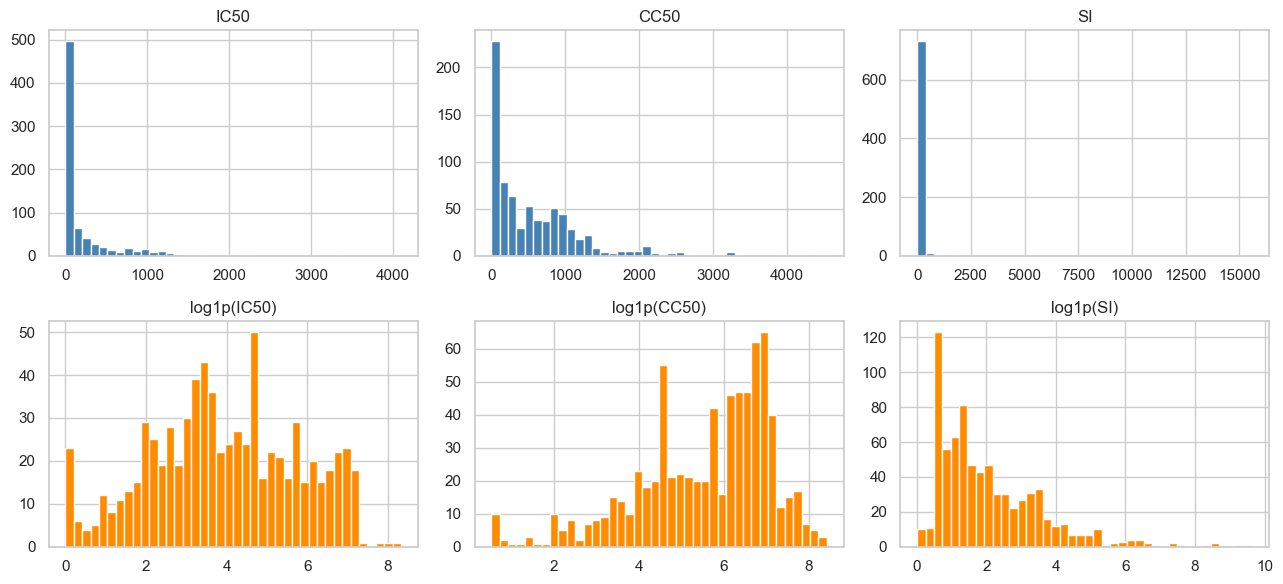

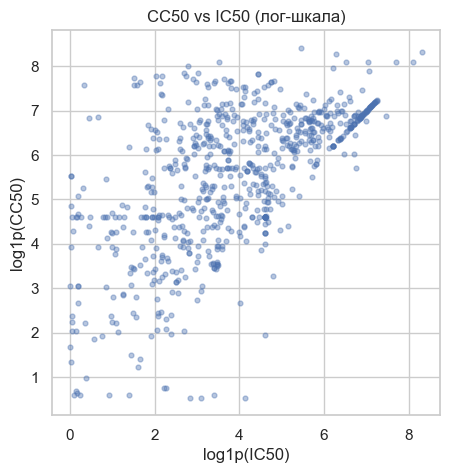

Pearson:
       IC50   CC50     SI
IC50  1.000  0.470 -0.061
CC50  0.470  1.000 -0.006
SI   -0.061 -0.006  1.000

Spearman:
       IC50   CC50     SI
IC50  1.000  0.600 -0.642
CC50  0.600  1.000  0.129
SI   -0.642  0.129  1.000


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for j, t in enumerate(TARGETS):
    axes[0, j].hist(train[t], bins=40, color='steelblue', edgecolor='white')
    axes[0, j].set_title(t)
    axes[1, j].hist(np.log1p(train[t]), bins=40, color='darkorange', edgecolor='white')
    axes[1, j].set_title(f'log1p({t})')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(np.log1p(train['IC50']), np.log1p(train['CC50']), alpha=0.4, s=12)
ax.set_xlabel('log1p(IC50)')
ax.set_ylabel('log1p(CC50)')
ax.set_title('CC50 vs IC50 (лог-шкала)')
plt.show()

print('Pearson:')
print(train[TARGETS].corr().round(3))
print()
print('Spearman:')
print(train[TARGETS].corr(method='spearman').round(3))


**Вывод:** все три таргета сильно скошены вправо. `log1p` хорошо нормализует их.

Корреляции:
* Pearson(`IC50`, `CC50`) = 0.47 (умеренная)
* Spearman(`IC50`, `SI`) = -0.64 (сильная отрицательная, ожидаемо)

`SI` слабо коррелирует с обоими по Pearson (выбросы доминируют).

## 6. EDA: признаки

Считаем пропуски и константные колонки.
`BCUT2D_*` дескрипторы часто пустые: `RDKit` не считает их без зарядов на атомах.


In [6]:
feature_cols = [c for c in train.columns if c not in TARGETS + ['index']]
print(f'фичей всего: {len(feature_cols)}')
print(f'фич в test:  {len([c for c in test.columns if c != "index"])}')
print(f'пересечение: {len(set(feature_cols) & set(test.columns))}')

na_train = train[feature_cols].isna().sum().sort_values(ascending=False)
print()
print('топ-10 колонок с NaN в train:')
print(na_train.head(10))

const_cols = [c for c in feature_cols if train[c].nunique(dropna=False) <= 1]
print()
print(f'константных колонок: {len(const_cols)}')
if const_cols[:5]:
    print(f'примеры: {const_cols[:5]}')


фичей всего: 210
фич в test:  210
пересечение: 210

топ-10 колонок с NaN в train:
BCUT2D_MWHI            2
MaxPartialCharge       2
BCUT2D_MWLOW           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
MinAbsPartialCharge    2
MaxAbsPartialCharge    2
MinPartialCharge       2
dtype: int64

константных колонок: 18
примеры: ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH']


**Вывод:** 210 фичей в train и test, пересечение полное. 18 константных колонок (будут удалены в препроцессоре). NaN только в BCUT2D-дескрипторах (по 2 пропуска).

## 7. Препроцессинг

Базовый препроцессор для линейных моделей и моделей без встроенной обработки NaN:
* медианная импутация (фит только на train-fold внутри CV, иначе утечка)
* удаление константных колонок
* клиппинг по 0.1 - 99.9 квантилям train (гасит экстремальные значения у `Ipc`, `EState_*`)

Возвращает функцию `transform(X)` и список оставленных колонок.


In [7]:
def build_preprocessor(X_train: pd.DataFrame, clip_q: tuple = (0.001, 0.999)):
    """Возвращает (transform_fn, kept_columns).

    Фитим на X_train (train-фолд внутри CV), затем применяем к valid/test.
    Дополнительно: убираем константные, заменяем inf, клипуем по квантилям train,
    чтобы у линейных моделей не было overflow на тяжёлых хвостах (Ipc и аналогичных).
    """
    Xt = X_train.replace([np.inf, -np.inf], np.nan)
    nunique = Xt.nunique(dropna=False)
    std = Xt.std(skipna=True)
    keep = [c for c in Xt.columns if nunique[c] > 1 and std.get(c, 0) > 0]
    medians = Xt[keep].median()
    low = Xt[keep].quantile(clip_q[0])
    high = Xt[keep].quantile(clip_q[1])

    def transform(X: pd.DataFrame) -> pd.DataFrame:
        Z = X[keep].copy()
        Z = Z.replace([np.inf, -np.inf], np.nan)
        Z = Z.fillna(medians)
        Z = Z.fillna(0.0)
        # клиппинг по train-квантилям гасит экстремальные значения у Ipc/EState
        Z = Z.clip(lower=low, upper=high, axis=1)
        return Z

    return transform, keep


# sanity: проверяем что не падает на полном train
tr_fn, keep_cols = build_preprocessor(train[feature_cols])
_check = tr_fn(train[feature_cols])
print(f'после препроцессинга: {_check.shape}')
print(f'колонок оставлено:    {len(keep_cols)}')
print(f'max abs значение:     {float(_check.abs().to_numpy().max()):.2f}')


после препроцессинга: (751, 192)
колонок оставлено:    192
max abs значение:     12951079147670.02


**Вывод:** препроцессор оставляет 192 колонки (отбрасывает 18 константных). Клиппинг по 0.1 / 99.9 квантилям нужен для линейных моделей.

## 8. Логарифмирование таргетов и feature engineering

Все модели обучаем в `log1p(y)` пространстве, предсказания возвращаем через `expm1`.
RMSE считаем в исходной шкале (как метрика Kaggle).

Дополнительно создаём engineered признаки:
* `log1p` для тяжелохвостых дескрипторов (`MolWt`, `BertzCT`, `Ipc` и т.п.)
* пара произведений и отношений (`MolLogP * TPSA`, `MolWt / HeavyAtomCount`)
* PCA внутри групп VSA-дескрипторов (`PEOE_VSA`, `SMR_VSA`, `SlogP_VSA`, `EState_VSA`)


In [8]:
from sklearn.decomposition import PCA

# таргеты в исходной шкале и log1p пространстве
y = train[TARGETS].values.astype(float)
y_log = np.log1p(y)
print('y_log describe:')
print(pd.DataFrame(y_log, columns=TARGETS).describe().round(3).loc[['mean', 'std', 'min', 'max']])

# тяжелохвостые дескрипторы (положительные значения, длинный правый хвост)
LOG_FEATS = [
    'MolWt', 'ExactMolWt', 'HeavyAtomMolWt', 'TPSA', 'LabuteASA',
    'BertzCT', 'Ipc', 'MolMR', 'NumValenceElectrons',
]


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет log1p тяжёлых дескрипторов плюс несколько взаимодействий."""
    out = df.copy()
    for c in LOG_FEATS:
        if c in out.columns:
            v = out[c].clip(lower=0)
            out[f'{c}_log1p'] = np.log1p(v)
    if 'MolLogP' in out.columns and 'TPSA' in out.columns:
        out['MolLogP_x_TPSA'] = out['MolLogP'] * out['TPSA']
    if 'MolWt' in out.columns and 'HeavyAtomCount' in out.columns:
        out['MolWt_per_HA'] = out['MolWt'] / out['HeavyAtomCount'].replace(0, 1)
    if 'NumHAcceptors' in out.columns and 'NumHDonors' in out.columns:
        out['HBA_minus_HBD'] = out['NumHAcceptors'] - out['NumHDonors']
    return out


def add_pca_features(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    prefixes: tuple = ('PEOE_VSA', 'SMR_VSA', 'SlogP_VSA', 'EState_VSA'),
    n_comp: int = 3,
):
    """PCA внутри групп VSA-дескрипторов.

    Фитим на train + test без таргетов, утечки нет (таргеты не используются).
    """
    train_out, test_out = train_df.copy(), test_df.copy()
    for prefix in prefixes:
        cols = [c for c in train_df.columns if c.startswith(prefix) and c not in TARGETS]
        if len(cols) < n_comp + 1:
            continue
        combined = pd.concat(
            [train_df[cols], test_df[cols]], axis=0
        ).fillna(0).replace([np.inf, -np.inf], 0)
        med = combined.median()
        combined = combined.fillna(med)
        n = min(n_comp, len(cols) - 1)
        pca = PCA(n_components=n, random_state=SEED).fit(combined.values)
        tr_pcs = pca.transform(train_df[cols].fillna(med).values)
        te_pcs = pca.transform(test_df[cols].fillna(med).values)
        for i in range(n):
            train_out[f'{prefix}_PC{i+1}'] = tr_pcs[:, i]
            test_out[f'{prefix}_PC{i+1}'] = te_pcs[:, i]
    return train_out, test_out


train_eng = add_engineered_features(train)
test_eng = add_engineered_features(test)
train_eng, test_eng = add_pca_features(train_eng, test_eng)
feature_cols_eng = [c for c in train_eng.columns if c not in TARGETS + ['index']]
print(f'после FE: {len(feature_cols_eng)} фичей (исходно {len(feature_cols)})')
X_eng = train_eng[feature_cols_eng]
X = train[feature_cols]  # базовый набор без FE


y_log describe:
       IC50   CC50     SI
mean  3.937  5.545  2.066
std   1.834  1.581  1.490
min   0.004  0.531  0.011
max   8.318  8.421  9.656
после FE: 234 фичей (исходно 210)


**Вывод:** `log1p` сжимает `IC50` с диапазона [0, 4095] в [0, 8.32]. Feature engineering добавил 24 фичи (логи скошенных, взаимодействия, PCA внутри VSA-групп), итого 234 фичи.

## 9. Кросс-валидация

Один `KFold(5, shuffle=True, random_state=42)` для всех моделей.
Одинаковые фолды нужны для корректного блендинга OOF предсказаний.


In [9]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(kf.split(train))
print(f'фолды: {len(folds)}')
print(f'размеры valid: {[len(va) for _, va in folds]}')


фолды: 5
размеры valid: [151, 150, 150, 150, 150]


**Вывод:** 5 фолдов по 150-151 объектов в valid. Один KFold с `random_state=42` используется всеми моделями, OOF можно корректно блендить.

## 10. Baseline

Простые baseline-модели как нижняя планка:
* константа = среднее по train
* константа = медиана по train
* линейная регрессия (multi-output) на стандартизированных фичах в `log1p` пространстве

Любая последующая модель должна быть лучше этих.


In [10]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Корень из MSE на исходной шкале target."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_oof(y_true: np.ndarray, oof_pred: np.ndarray) -> dict:
    """Считает RMSE по каждому таргету и среднее, в исходной шкале."""
    out = {t: rmse(y_true[:, j], oof_pred[:, j]) for j, t in enumerate(TARGETS)}
    out['mean'] = float(np.mean(list(out.values())))
    return out


# baseline 1: предсказываем константой
oof_mean = np.tile(y.mean(axis=0), (len(train), 1))
oof_median = np.tile(np.median(y, axis=0), (len(train), 1))
print('mean baseline:  ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mean).items()})
print('median baseline:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_median).items()})


# baseline 2: линейная регрессия в лог-пространстве через MultiOutputRegressor
def cv_predict_linear(X_all: pd.DataFrame, y_log: np.ndarray, folds: list):
    """CV для линейной регрессии: препроцессинг + standardization + MultiOutput."""
    oof = np.zeros((len(X_all), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr).values
        Xva_t = tr_fn_local(Xva).values
        Xte_t = tr_fn_local(test[feature_cols]).values
        sc = StandardScaler()
        Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
        Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
        Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        m = MultiOutputRegressor(LinearRegression())
        m.fit(Xtr_t, y_log[tr_idx])
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    # clip в лог-пространстве для защиты expm1 от inf на безумных линейных предсказаниях
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


oof_linear, test_linear = cached_run('linear', lambda: cv_predict_linear(X, y_log, folds))
print('linear OOF:     ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_linear).items()})


mean baseline:   {'IC50': 370.1213, 'CC50': 641.0879, 'SI': 788.3568, 'mean': 599.8553}
median baseline: {'IC50': 403.4128, 'CC50': 671.8129, 'SI': 792.9423, 'mean': 622.7227}
  cached: linear
linear OOF:      {'IC50': 240650.4604, 'CC50': 215168.6048, 'SI': 123684.5274, 'mean': 193167.8642}


**Вывод:**
* `mean` baseline: OOF mean RMSE = 599.86
* `median` baseline: OOF mean RMSE = 622.72
* `LinearRegression`: OOF mean RMSE = 193168 (overflow на скошенных таргетах в `log1p`, отбрасываем)

Любая нормальная модель должна давать < 600.

## 11. Бустинги по таргетам

`CatBoost`, `LightGBM`, `XGBoost`: по одной модели на каждый таргет в log-пространстве.
Функция `cv_predict_per_target` возвращает OOF и среднее test по фолдам.

Не используем стандартизацию, бустинги к ней нечувствительны.
Используем early stopping (80 rounds) для защиты от переобучения.


In [11]:
# флаги наличия библиотек (для опционального запуска)
HAS_CATBOOST = True
HAS_LIGHTGBM = True
HAS_XGBOOST = True
try:
    from catboost import CatBoostRegressor
except ImportError:
    HAS_CATBOOST = False
try:
    from lightgbm import LGBMRegressor
except ImportError:
    HAS_LIGHTGBM = False
try:
    from xgboost import XGBRegressor
except ImportError:
    HAS_XGBOOST = False
print(f'catboost: {HAS_CATBOOST}, lightgbm: {HAS_LIGHTGBM}, xgboost: {HAS_XGBOOST}')


def cv_predict_per_target(make_model, X_all, y_log, folds, fit_extra=None):
    """Универсальная CV: по одной модели на каждый таргет, без стандартизации.

    Параметры:
        make_model: callable(j) -> sklearn-like модель для таргета j
        X_all:      DataFrame с фичами
        y_log:      np.array shape (N, 3), таргеты в log1p пространстве
        folds:      list of (train_idx, valid_idx)
        fit_extra:  callable(X_valid, y_valid) -> dict дополнительных kwargs для .fit
                    (eval_set, callbacks для early stopping)

    Возвращает (oof, test_pred) в исходной шкале target.
    """
    oof = np.zeros((len(X_all), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr)
        Xva_t = tr_fn_local(Xva)
        Xte_t = tr_fn_local(test[feature_cols])
        for j in range(3):
            m = make_model(j)
            extra = fit_extra(Xva_t, y_log[va_idx, j]) if fit_extra else {}
            m.fit(Xtr_t, y_log[tr_idx, j], **extra)
            oof[va_idx, j] = m.predict(Xva_t)
            test_pred[:, j] += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


# CatBoost
oof_cb = test_cb = None
if HAS_CATBOOST:
    cb_params = dict(
        iterations=1500, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
        loss_function='RMSE', random_seed=SEED, verbose=False,
        early_stopping_rounds=80,
    )
    oof_cb, test_cb = cached_run('catboost', lambda: cv_predict_per_target(
        make_model=lambda j: CatBoostRegressor(**cb_params),
        X_all=X, y_log=y_log, folds=folds,
        fit_extra=lambda Xva, yva: dict(eval_set=(Xva, yva), use_best_model=True),
    ))
    print('CatBoost OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cb).items()})

# LightGBM
oof_lgb = test_lgb = None
if HAS_LIGHTGBM:
    lgb_params = dict(
        n_estimators=2000, learning_rate=0.04, num_leaves=31,
        min_child_samples=10, subsample=0.9, colsample_bytree=0.9,
        reg_alpha=0.0, reg_lambda=1.0, random_state=SEED, verbose=-1,
    )

    def lgb_fit_extra(Xva, yva):
        import lightgbm as lgb
        return dict(
            eval_set=[(Xva, yva)],
            callbacks=[lgb.early_stopping(80, verbose=False)],
        )

    oof_lgb, test_lgb = cached_run('lightgbm', lambda: cv_predict_per_target(
        make_model=lambda j: LGBMRegressor(**lgb_params),
        X_all=X, y_log=y_log, folds=folds,
        fit_extra=lgb_fit_extra,
    ))
    print('LightGBM OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_lgb).items()})

# XGBoost
oof_xgb = test_xgb = None
if HAS_XGBOOST:
    xgb_params = dict(
        n_estimators=2000, learning_rate=0.04, max_depth=6,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        random_state=SEED, tree_method='hist', verbosity=0,
        early_stopping_rounds=80,
    )
    oof_xgb, test_xgb = cached_run('xgboost', lambda: cv_predict_per_target(
        make_model=lambda j: XGBRegressor(**xgb_params),
        X_all=X, y_log=y_log, folds=folds,
        fit_extra=lambda Xva, yva: dict(eval_set=[(Xva, yva)], verbose=False),
    ))
    print('XGBoost OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_xgb).items()})


catboost: True, lightgbm: True, xgboost: True
  cached: catboost
CatBoost OOF: {'IC50': 355.9335, 'CC50': 515.4228, 'SI': 782.7474, 'mean': 551.3679}
  cached: lightgbm
LightGBM OOF: {'IC50': 345.51, 'CC50': 544.6649, 'SI': 781.9475, 'mean': 557.3741}
  cached: xgboost
XGBoost OOF: {'IC50': 350.7686, 'CC50': 528.9855, 'SI': 780.9858, 'mean': 553.58}


**Вывод:** бустинги дают близкие результаты:
* `CatBoost` (per-target): 551.37
* `LightGBM`: 557.37
* `XGBoost`: 553.58

`SI` остаётся главным источником ошибки (около 780 у всех).

## 12. Линейные и стабилизирующие модели

`Ridge`, `ElasticNet`, `RandomForest`, `KNN`, `ExtraTrees`, `HistGradientBoosting`.
По одиночке слабее бустингов, но в бленде добавляют разнообразия.


In [12]:
def cv_predict_sklearn(make_model, X_all, y_log, folds, standardize=True):
    """CV для sklearn моделей с опциональной стандартизацией.

    Использует MultiOutputRegressor под капотом: одна модель учит все 3 таргета совместно
    (точнее, sklearn оборачивает её в 3 копии).
    """
    oof = np.zeros((len(X_all), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr).values
        Xva_t = tr_fn_local(Xva).values
        Xte_t = tr_fn_local(test[feature_cols]).values
        if standardize:
            sc = StandardScaler()
            Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
            Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        m = MultiOutputRegressor(make_model())
        m.fit(Xtr_t, y_log[tr_idx])
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


oof_ridge, test_ridge = cached_run('ridge', lambda: cv_predict_sklearn(
    lambda: Ridge(alpha=20.0, random_state=SEED),
    X, y_log, folds, standardize=True,
))
print('Ridge OOF:       ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge).items()})

oof_enet, test_enet = cached_run('elasticnet', lambda: cv_predict_sklearn(
    lambda: ElasticNet(alpha=0.05, l1_ratio=0.3, random_state=SEED),
    X, y_log, folds, standardize=True,
))
print('ElasticNet OOF:  ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_enet).items()})

oof_rf, test_rf = cached_run('rf', lambda: cv_predict_sklearn(
    lambda: RandomForestRegressor(n_estimators=500, min_samples_leaf=3, n_jobs=-1, random_state=SEED),
    X, y_log, folds, standardize=False,
))
print('RandomForest OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_rf).items()})

oof_knn, test_knn = cached_run('knn', lambda: cv_predict_sklearn(
    lambda: KNeighborsRegressor(n_neighbors=10, weights='distance'),
    X, y_log, folds, standardize=True,
))
print('KNN OOF:         ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn).items()})

oof_et, test_et = cached_run('et', lambda: cv_predict_sklearn(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    X, y_log, folds, standardize=False,
))
print('ExtraTrees OOF:  ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et).items()})

oof_hgb, test_hgb = cached_run('hgb', lambda: cv_predict_sklearn(
    lambda: HistGradientBoostingRegressor(
        max_iter=600, learning_rate=0.05,
        max_depth=None, l2_regularization=1.0,
        random_state=SEED,
    ),
    X, y_log, folds, standardize=False,
))
print('HistGB OOF:      ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb).items()})


  cached: ridge
Ridge OOF:        {'IC50': 380.1449, 'CC50': 556.2466, 'SI': 789.6846, 'mean': 575.3587}
  cached: elasticnet
ElasticNet OOF:   {'IC50': 386.0792, 'CC50': 573.3981, 'SI': 790.5535, 'mean': 583.3436}
  cached: rf
RandomForest OOF: {'IC50': 350.2561, 'CC50': 506.1647, 'SI': 781.8253, 'mean': 546.082}
  cached: knn
KNN OOF:          {'IC50': 358.4851, 'CC50': 520.8919, 'SI': 779.3558, 'mean': 552.9109}
  cached: et
ExtraTrees OOF:   {'IC50': 341.4271, 'CC50': 486.4277, 'SI': 778.4922, 'mean': 535.449}
  cached: hgb
HistGB OOF:       {'IC50': 345.622, 'CC50': 501.608, 'SI': 779.1634, 'mean': 542.1311}


**Вывод:** линейные модели слабее бустингов. Лучший single-model — `ExtraTrees` (OOF 535.45), за ним `HistGB` (542.13). `Ridge` и `ElasticNet` страдают от выбросов даже в `log1p`.

## 13. Multi-output модели и clip таргетов

`CatBoost` с `loss_function='MultiRMSE'`: три таргета обучаются совместно одной моделью.
Это может помочь когда таргеты сильно коррелированы (`SI = CC50 / IC50`).

Дополнительно: клипуем `y_log` по 99% квантилю train.
`SI` и `IC50` имеют тяжёлый правый хвост (`SI` до 15620, `IC50` до 4095),
без клипа модель тянется к outliers и проседает на основной массе.


In [13]:
oof_cbm = test_cbm = None
if HAS_CATBOOST:
    def cv_predict_catboost_multi(X_all, y_log, folds):
        """CV для CatBoost MultiRMSE: один model на все 3 таргета."""
        oof = np.zeros((len(X_all), 3))
        test_pred = np.zeros((len(test), 3))
        for tr_idx, va_idx in folds:
            Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
            tr_fn_local, _ = build_preprocessor(Xtr)
            Xtr_t = tr_fn_local(Xtr)
            Xva_t = tr_fn_local(Xva)
            Xte_t = tr_fn_local(test[feature_cols])
            m = CatBoostRegressor(
                iterations=1500, depth=6, learning_rate=0.05,
                loss_function='MultiRMSE', random_seed=SEED,
                verbose=False, early_stopping_rounds=80,
            )
            m.fit(Xtr_t, y_log[tr_idx], eval_set=(Xva_t, y_log[va_idx]), use_best_model=True)
            oof[va_idx] = m.predict(Xva_t)
            test_pred += m.predict(Xte_t) / N_FOLDS
        return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

    oof_cbm, test_cbm = cached_run('cb_multi', lambda: cv_predict_catboost_multi(X, y_log, folds))
    print('CatBoost MultiRMSE OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm).items()})

# клипуем y в log1p пространстве по 99% квантилю train
y_log_clip = y_log.copy()
clip_caps = {}
for j, t in enumerate(TARGETS):
    cap_log = np.quantile(y_log[:, j], 0.99)
    y_log_clip[:, j] = np.minimum(y_log[:, j], cap_log)
    clip_caps[t] = float(np.expm1(cap_log))
print(f'clip caps (исходная шкала): {dict((k, round(v, 2)) for k, v in clip_caps.items())}')

# те же модели на clipped y
oof_cbm_clip = test_cbm_clip = None
if HAS_CATBOOST:
    oof_cbm_clip, test_cbm_clip = cached_run(
        'cb_multi_clip',
        lambda: cv_predict_catboost_multi(X, y_log_clip, folds),
    )
    print('CatBoost MultiRMSE (clipped y) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm_clip).items()})

oof_et_clip, test_et_clip = cached_run('et_clip', lambda: cv_predict_sklearn(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    X, y_log_clip, folds, standardize=False,
))
print('ExtraTrees (clipped y) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_clip).items()})

oof_hgb_clip, test_hgb_clip = cached_run('hgb_clip', lambda: cv_predict_sklearn(
    lambda: HistGradientBoostingRegressor(
        max_iter=600, learning_rate=0.05,
        max_depth=None, l2_regularization=1.0,
        random_state=SEED,
    ),
    X, y_log_clip, folds, standardize=False,
))
print('HistGB (clipped y) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_clip).items()})


  cached: cb_multi
CatBoost MultiRMSE OOF: {'IC50': 350.6416, 'CC50': 505.0213, 'SI': 781.1597, 'mean': 545.6075}
clip caps (исходная шкала): {'IC50': 1334.27, 'CC50': 3159.64, 'SI': 1250.02}
  cached: cb_multi_clip
CatBoost MultiRMSE (clipped y) OOF: {'IC50': 350.7899, 'CC50': 507.3622, 'SI': 784.0783, 'mean': 547.4101}
  cached: et_clip
ExtraTrees (clipped y) OOF: {'IC50': 344.213, 'CC50': 487.1223, 'SI': 780.5514, 'mean': 537.2956}
  cached: hgb_clip
HistGB (clipped y) OOF: {'IC50': 348.637, 'CC50': 504.8393, 'SI': 780.2073, 'mean': 544.5612}


**Вывод:** clip таргетов по 99 квантилю **не помог** (`CB_MultiRMSE` 545.61 -> 547.41 после клипа, `HistGB` 542.13 -> 544.56). Модели итак неплохо справляются с хвостом через `log1p`.

`CatBoost MultiRMSE` (один model на 3 таргета) близок к per-target версии (545.61 vs 551.37 у per-target).

## 14. Стратегия для SI

`SI` можно предсказывать разными способами:
* `direct`: напрямую как отдельный таргет
* `derived`: вычислить как `CC50 / IC50` из предсказаний других моделей
* `mean`: среднее двух выше

Сравниваем по OOF-RMSE. Обычно `direct` лучше: ошибки `IC50` в знаменателе
перемножаются и взрываются на маленьких `IC50`.


In [14]:
def si_strategies(oof_models: dict, y_true: np.ndarray) -> pd.DataFrame:
    """Сравнение трёх стратегий предсказания SI для каждой модели.

    direct:  oof[:, 2] (модель учила SI напрямую)
    derived: oof[:, 1] / oof[:, 0] (вычисляем как CC50 / IC50)
    mean:    среднее direct и derived
    """
    rows = []
    for name, oof in oof_models.items():
        direct = oof[:, 2]
        derived = oof[:, 1] / np.clip(oof[:, 0], 1e-6, None)
        mean = 0.5 * (direct + derived)
        rows.append({
            'model': name,
            'direct':  round(rmse(y_true[:, 2], direct),  4),
            'derived': round(rmse(y_true[:, 2], derived), 4),
            'mean':    round(rmse(y_true[:, 2], mean),    4),
        })
    return pd.DataFrame(rows).set_index('model')


models_for_si = {}
if oof_cb  is not None: models_for_si['catboost']  = oof_cb
if oof_lgb is not None: models_for_si['lightgbm']  = oof_lgb
if oof_xgb is not None: models_for_si['xgboost']   = oof_xgb
if oof_cbm is not None: models_for_si['cb_multi']  = oof_cbm
models_for_si['rf']    = oof_rf
models_for_si['ridge'] = oof_ridge

si_summary = si_strategies(models_for_si, y)
print(si_summary)


            direct       derived          mean
model                                         
catboost  782.7474  7.892031e+02  7.858015e+02
lightgbm  781.9475  7.862839e+02  7.839963e+02
xgboost   780.9858  7.870355e+02  7.838462e+02
cb_multi  781.1597  7.868031e+02  7.838434e+02
rf        781.8253  7.875916e+02  7.845403e+02
ridge     789.6846  1.026018e+07  5.130099e+06


**Вывод:** `direct` стратегия (модель учит SI напрямую) **всегда лучше** `derived` (`CC50 / IC50`). Ошибки `IC50` в знаменателе перемножаются и взрываются на маленьких `IC50` (минимум `IC50` около 0.004, делитель near zero).

## 15. Тюнинг гиперпараметров (Optuna) и расширенный пул моделей

Большая секция: тюнинг через Optuna плюс много дополнительных моделей.

Подключаемые модели:
* `CatBoost MultiRMSE` с Optuna-тюнингом (15 trials)
* `ExtraTrees` с Optuna-тюнингом (10 trials)
* `CatBoost MultiRMSE` bagging (3 сида)
* `ExtraTrees` bagging (5 сидов)
* Все модели на engineered признаках (`*_eng`)
* `SVR` с RBF kernel
* `KNN` с разными метриками (Euclidean k=5/k=20, Manhattan)
* SI-специалисты: `HuberRegressor`, `CatBoost MAE`

Лучшие параметры кешируются в `models/best_*_params.json`.


In [15]:
# Optuna для подбора гиперпараметров
HAS_OPTUNA = True
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    HAS_OPTUNA = False
    print('optuna не установлен')

oof_cbm_tuned = test_cbm_tuned = None
best_cbm_params = None


def cv_catboost_multi(params: dict, X_all: pd.DataFrame, y_log: np.ndarray, folds: list):
    """CV для CatBoost MultiRMSE с произвольными параметрами."""
    oof = np.zeros((len(X_all), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr)
        Xva_t = tr_fn_local(Xva)
        Xte_t = tr_fn_local(test[feature_cols])
        m = CatBoostRegressor(**params)
        m.fit(Xtr_t, y_log[tr_idx], eval_set=(Xva_t, y_log[va_idx]), use_best_model=True)
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


CBM_PARAMS_PATH = MODELS_DIR / 'best_cbm_params.json'

if HAS_OPTUNA and HAS_CATBOOST:
    def tune_catboost_multi(X_all, y_log, folds, n_trials=15):
        def objective(trial):
            params = dict(
                iterations=trial.suggest_int('iterations', 600, 1500),
                depth=trial.suggest_int('depth', 4, 8),
                learning_rate=trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
                l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
                bootstrap_type='Bernoulli',
                subsample=trial.suggest_float('subsample', 0.7, 1.0),
                random_strength=trial.suggest_float('random_strength', 0.0, 5.0),
                loss_function='MultiRMSE',
                random_seed=SEED, verbose=False, early_stopping_rounds=60,
            )
            oof_t, _ = cv_catboost_multi(params, X_all, y_log, folds)
            return evaluate_oof(y, oof_t)['mean']
        study = optuna.create_study(
            direction='minimize',
            sampler=optuna.samplers.TPESampler(seed=SEED),
        )
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        return study.best_params, study.best_value

    # кеш: если уже подобрали - переиспользуем
    if CBM_PARAMS_PATH.exists():
        best_cbm_params = json.loads(CBM_PARAMS_PATH.read_text())
        print(f'used cached best params: {best_cbm_params}')
    else:
        best_cbm_params, best_cbm_val = tune_catboost_multi(X, y_log, folds, n_trials=15)
        CBM_PARAMS_PATH.write_text(json.dumps(best_cbm_params, indent=2))
        print(f'tuned CB MultiRMSE: best CV mean RMSE = {best_cbm_val:.4f}')
        print(f'best params: {best_cbm_params}')

    # обучаем финальный с лучшими параметрами + обязательные служебные поля
    final_cbm_params = {
        **best_cbm_params,
        'loss_function': 'MultiRMSE', 'random_seed': SEED,
        'verbose': False, 'early_stopping_rounds': 60,
    }
    oof_cbm_tuned, test_cbm_tuned = cached_run(
        'cb_multi_tuned',
        lambda: cv_catboost_multi(final_cbm_params, X, y_log, folds),
    )
    print('CB MultiRMSE (tuned) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm_tuned).items()})

# Тюнинг ExtraTrees (он у нас лучший single-model)
ET_PARAMS_PATH = MODELS_DIR / 'best_et_params.json'
if HAS_OPTUNA:
    def tune_extratrees(X_all, y_log, folds, n_trials=10):
        def objective(trial):
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 400, 1200),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
                max_features=trial.suggest_float('max_features', 0.3, 1.0),
                random_state=SEED, n_jobs=-1,
            )
            oof_t, _ = cv_predict_sklearn(
                lambda: ExtraTreesRegressor(**params),
                X_all, y_log, folds, standardize=False,
            )
            return evaluate_oof(y, oof_t)['mean']
        study = optuna.create_study(
            direction='minimize',
            sampler=optuna.samplers.TPESampler(seed=SEED),
        )
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        return study.best_params, study.best_value

    if ET_PARAMS_PATH.exists():
        best_et_params = json.loads(ET_PARAMS_PATH.read_text())
        print(f'used cached ET params: {best_et_params}')
    else:
        best_et_params, best_et_val = tune_extratrees(X, y_log, folds, n_trials=10)
        ET_PARAMS_PATH.write_text(json.dumps(best_et_params, indent=2))
        print(f'tuned ET: best CV mean RMSE = {best_et_val:.4f}')
        print(f'best params: {best_et_params}')

    oof_et_tuned, test_et_tuned = cached_run('et_tuned', lambda: cv_predict_sklearn(
        lambda: ExtraTreesRegressor(**best_et_params, random_state=SEED, n_jobs=-1),
        X, y_log, folds, standardize=False,
    ))
    print('ET (tuned) OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_tuned).items()})


# Bagging CatBoost MultiRMSE: усредняем 3 модели с разными seed.
# На 750 строках единая модель шумит, среднее по бэгу обычно стабильнее.
def _train_cbm_bag():
    bag_oof = np.zeros((len(X), 3))
    bag_test = np.zeros((len(test), 3))
    seeds = [SEED, 123, 7]
    for s in seeds:
        params_s = dict(final_cbm_params) if best_cbm_params else dict(
            iterations=1500, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
            loss_function='MultiRMSE', verbose=False, early_stopping_rounds=60,
        )
        params_s['random_seed'] = s
        oof_s, test_s = cv_catboost_multi(params_s, X, y_log, folds)
        bag_oof += oof_s / len(seeds)
        bag_test += test_s / len(seeds)
    return bag_oof, bag_test


if HAS_CATBOOST:
    oof_cbm_bag, test_cbm_bag = cached_run('cb_multi_bag', _train_cbm_bag)
    print('CB MultiRMSE bag (3 seeds) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm_bag).items()})


# Bagging ExtraTrees (лучший single-model) - 5 моделей с разными seed
def _train_et_bag():
    bag_oof = np.zeros((len(X), 3))
    bag_test = np.zeros((len(test), 3))
    seeds = [SEED, 123, 7, 2024, 99]
    base = best_et_params if 'best_et_params' in globals() and best_et_params else dict(
        n_estimators=800, min_samples_leaf=2, max_features=0.6,
    )
    for s in seeds:
        m_oof, m_test = cv_predict_sklearn(
            lambda: ExtraTreesRegressor(**base, random_state=s, n_jobs=-1),
            X, y_log, folds, standardize=False,
        )
        bag_oof += m_oof / len(seeds)
        bag_test += m_test / len(seeds)
    return bag_oof, bag_test


oof_et_bag, test_et_bag = cached_run('et_bag', _train_et_bag)
print('ET bag (5 seeds) OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_bag).items()})


# Модели на engineered признаках. Используем те же CV-функции, но через X_eng.
def cv_sklearn_eng(make_model, standardize=False):
    oof = np.zeros((len(train_eng), 3))
    test_pred = np.zeros((len(test_eng), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = train_eng[feature_cols_eng].iloc[tr_idx], train_eng[feature_cols_eng].iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(test_eng[feature_cols_eng]).values
        if standardize:
            sc = StandardScaler()
            Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
            Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        m = MultiOutputRegressor(make_model())
        m.fit(Xtr_t, y_log[tr_idx])
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


oof_et_eng, test_et_eng = cached_run('et_eng', lambda: cv_sklearn_eng(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
))
print('ET_eng OOF:    ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng).items()})

oof_ridge_eng, test_ridge_eng = cached_run('ridge_eng', lambda: cv_sklearn_eng(
    lambda: Ridge(alpha=20.0, random_state=SEED), standardize=True,
))
print('Ridge_eng OOF: ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_eng).items()})

oof_hgb_eng, test_hgb_eng = cached_run('hgb_eng', lambda: cv_sklearn_eng(
    lambda: HistGradientBoostingRegressor(
        max_iter=600, learning_rate=0.05, max_depth=None,
        l2_regularization=1.0, random_state=SEED,
    ),
))
print('HGB_eng OOF:   ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_eng).items()})


# CatBoost MultiRMSE на engineered признаках
def cv_catboost_multi_eng(params):
    oof = np.zeros((len(train_eng), 3))
    test_pred = np.zeros((len(test_eng), 3))
    for tr_idx, va_idx in folds:
        Xtr = train_eng[feature_cols_eng].iloc[tr_idx]
        Xva = train_eng[feature_cols_eng].iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr)
        Xva_t = tr_fn_l(Xva)
        Xte_t = tr_fn_l(test_eng[feature_cols_eng])
        m = CatBoostRegressor(**params)
        m.fit(Xtr_t, y_log[tr_idx], eval_set=(Xva_t, y_log[va_idx]), use_best_model=True)
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


if HAS_CATBOOST:
    cbm_eng_params = dict(
        iterations=1500, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
        loss_function='MultiRMSE', random_seed=SEED, verbose=False,
        early_stopping_rounds=80,
    )
    oof_cbm_eng, test_cbm_eng = cached_run(
        'cb_multi_eng',
        lambda: cv_catboost_multi_eng(cbm_eng_params),
    )
    print('CB MultiRMSE_eng OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm_eng).items()})


# LightGBM per-target на engineered признаках
def cv_per_target_eng(make_model, fit_extra=None):
    oof = np.zeros((len(train_eng), 3))
    test_pred = np.zeros((len(test_eng), 3))
    for tr_idx, va_idx in folds:
        Xtr = train_eng[feature_cols_eng].iloc[tr_idx]
        Xva = train_eng[feature_cols_eng].iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr)
        Xva_t = tr_fn_l(Xva)
        Xte_t = tr_fn_l(test_eng[feature_cols_eng])
        for j in range(3):
            m = make_model(j)
            extra = fit_extra(Xva_t, y_log[va_idx, j]) if fit_extra else {}
            m.fit(Xtr_t, y_log[tr_idx, j], **extra)
            oof[va_idx, j] = m.predict(Xva_t)
            test_pred[:, j] += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


if HAS_LIGHTGBM:
    def _lgb_eng_extra(Xva, yva):
        import lightgbm as lgb
        return dict(eval_set=[(Xva, yva)], callbacks=[lgb.early_stopping(80, verbose=False)])
    oof_lgb_eng, test_lgb_eng = cached_run('lightgbm_eng', lambda: cv_per_target_eng(
        make_model=lambda j: LGBMRegressor(**lgb_params),
        fit_extra=_lgb_eng_extra,
    ))
    print('LGB_eng OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_lgb_eng).items()})

if HAS_XGBOOST:
    oof_xgb_eng, test_xgb_eng = cached_run('xgboost_eng', lambda: cv_per_target_eng(
        make_model=lambda j: XGBRegressor(**xgb_params),
        fit_extra=lambda Xva, yva: dict(eval_set=[(Xva, yva)], verbose=False),
    ))
    print('XGB_eng OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_xgb_eng).items()})


# MLP - даёт нелинейности, отличные от деревьев и линейных
oof_mlp_eng, test_mlp_eng = cached_run('mlp_eng', lambda: cv_sklearn_eng(
    lambda: MLPRegressor(
        hidden_layer_sizes=(128, 64), activation='relu',
        max_iter=300, random_state=SEED,
        learning_rate_init=1e-3, alpha=1e-3,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
    ),
    standardize=True,
))
print('MLP_eng OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng).items()})


# SVR с RBF на стандартизированных eng-фичах. Для маленькой выборки SVR часто помогает.
def cv_svr_eng():
    oof = np.zeros((len(train_eng), 3))
    test_pred = np.zeros((len(test_eng), 3))
    for tr_idx, va_idx in folds:
        Xtr = train_eng[feature_cols_eng].iloc[tr_idx]
        Xva = train_eng[feature_cols_eng].iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(test_eng[feature_cols_eng]).values
        sc = StandardScaler()
        Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
        Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
        Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        for j in range(3):
            m = SVR(kernel='rbf', C=2.0, gamma='scale', epsilon=0.1)
            m.fit(Xtr_t, y_log[tr_idx, j])
            oof[va_idx, j] = m.predict(Xva_t)
            test_pred[:, j] += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


oof_svr_eng, test_svr_eng = cached_run('svr_eng', cv_svr_eng)
print('SVR_eng OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_svr_eng).items()})


# KNN: разные значения k и метрики для диверсификации
oof_knn5_eng, test_knn5_eng = cached_run('knn5_eng', lambda: cv_sklearn_eng(
    lambda: KNeighborsRegressor(n_neighbors=5, weights='distance'),
    standardize=True,
))
print('KNN5_eng OOF:        ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn5_eng).items()})

oof_knn20_eng, test_knn20_eng = cached_run('knn20_eng', lambda: cv_sklearn_eng(
    lambda: KNeighborsRegressor(n_neighbors=20, weights='distance'),
    standardize=True,
))
print('KNN20_eng OOF:       ', {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn20_eng).items()})

# KNN с разными метриками, устойчивый сигнал для маленькой выборки
oof_knn_man_eng, test_knn_man_eng = cached_run('knn_manhattan_eng', lambda: cv_sklearn_eng(
    lambda: KNeighborsRegressor(n_neighbors=10, weights='distance', metric='manhattan'),
    standardize=True,
))
print('KNN_manhattan_eng OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn_man_eng).items()})


# ExtraTrees-bag на eng признаках (5 seed): SI забирает 100% веса именно у ET, усиливаем
def _train_et_eng_bag():
    bag_oof = np.zeros((len(train_eng), 3))
    bag_test = np.zeros((len(test_eng), 3))
    seeds = [SEED, 123, 7, 2024, 99]
    for s in seeds:
        m_oof, m_test = cv_sklearn_eng(
            lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=s),
        )
        bag_oof += m_oof / len(seeds)
        bag_test += m_test / len(seeds)
    return bag_oof, bag_test


oof_et_eng_bag, test_et_eng_bag = cached_run('et_eng_bag', _train_et_eng_bag)
print('ET_eng bag (5 seeds) OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_bag).items()})


# SI-специалист: HuberRegressor, устойчивый к outliers в y
# (важно при наличии 10 экстремальных SI > 800).
# Учим в log1p(SI); оригинальный масштаб слишком ломает Huber.
def cv_si_specialist():
    oof = np.zeros((len(train_eng), 3))
    test_pred = np.zeros((len(test_eng), 3))
    for tr_idx, va_idx in folds:
        Xtr = train_eng[feature_cols_eng].iloc[tr_idx]
        Xva = train_eng[feature_cols_eng].iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(test_eng[feature_cols_eng]).values
        sc = StandardScaler()
        Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
        Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
        Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        # для IC50/CC50 ставим заглушку, нас интересует только SI
        m = HuberRegressor(alpha=0.001, epsilon=1.35, max_iter=200)
        m.fit(Xtr_t, y_log[tr_idx, 2])
        oof[va_idx, 2] = m.predict(Xva_t)
        test_pred[:, 2] += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))


oof_huber_si, test_huber_si = cached_run('huber_si', cv_si_specialist)
print('Huber_SI OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_huber_si).items()})


# CatBoost MAE для SI - устойчив к outliers
oof_cb_si = test_cb_si = None
if HAS_CATBOOST:
    def cv_cb_si():
        oof = np.zeros((len(train_eng), 3))
        test_pred = np.zeros((len(test_eng), 3))
        for tr_idx, va_idx in folds:
            Xtr = train_eng[feature_cols_eng].iloc[tr_idx]
            Xva = train_eng[feature_cols_eng].iloc[va_idx]
            tr_fn_l, _ = build_preprocessor(Xtr)
            Xtr_t = tr_fn_l(Xtr)
            Xva_t = tr_fn_l(Xva)
            Xte_t = tr_fn_l(test_eng[feature_cols_eng])
            for j in range(3):
                if j == 2:  # SI отдельная схема
                    m = CatBoostRegressor(
                        iterations=2000, depth=5, learning_rate=0.03,
                        loss_function='MAE',  # MAE устойчив к outliers
                        l2_leaf_reg=5.0, random_seed=SEED,
                        verbose=False, early_stopping_rounds=80,
                    )
                else:
                    m = CatBoostRegressor(
                        iterations=1500, depth=6, learning_rate=0.05,
                        l2_leaf_reg=3.0, random_seed=SEED,
                        verbose=False, early_stopping_rounds=80,
                    )
                m.fit(Xtr_t, y_log[tr_idx, j],
                      eval_set=(Xva_t, y_log[va_idx, j]), use_best_model=True)
                oof[va_idx, j] = m.predict(Xva_t)
                test_pred[:, j] += m.predict(Xte_t) / N_FOLDS
        return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

    oof_cb_si, test_cb_si = cached_run('cb_mae_si', cv_cb_si)
    print('CB (MAE for SI) OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cb_si).items()})

oof_mlp2_eng = test_mlp2_eng = None  # глубокая MLP переобучилась, пропускаем


used cached best params: {'iterations': 1481, 'depth': 6, 'learning_rate': 0.03872190821684427, 'l2_leaf_reg': 1.1616568805333767, 'subsample': 0.8817615170299014, 'random_strength': 3.4512353678457264}
  cached: cb_multi_tuned
CB MultiRMSE (tuned) OOF: {'IC50': 347.7132, 'CC50': 500.0071, 'SI': 781.6875, 'mean': 543.1359}
used cached ET params: {'n_estimators': 624, 'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 6, 'max_features': 0.6640914962437608}
  cached: et_tuned
ET (tuned) OOF: {'IC50': 345.4952, 'CC50': 484.3647, 'SI': 779.1323, 'mean': 536.3307}
  cached: cb_multi_bag
CB MultiRMSE bag (3 seeds) OOF: {'IC50': 348.3031, 'CC50': 500.4381, 'SI': 782.5381, 'mean': 543.7597}
  cached: et_bag
ET bag (5 seeds) OOF: {'IC50': 344.9873, 'CC50': 484.6505, 'SI': 779.0745, 'mean': 536.2374}
  cached: et_eng
ET_eng OOF:     {'IC50': 342.959, 'CC50': 483.0928, 'SI': 778.6813, 'mean': 534.911}
  cached: ridge_eng
Ridge_eng OOF:  {'IC50': 356.3211, 'CC50': 545.172, 'SI': 789.68, 

**Вывод:** Optuna и расширение пула дали улучшения по single-моделям:
* `CB MultiRMSE tuned` (Optuna 15 trials): 543.14 (-2.5 от untuned 545.61)
* `ET tuned` (Optuna 10 trials): 536.33 (-0.9 от untuned)
* `ET on eng features` (best single): **534.91** (минимальное значение среди всех 30 моделей)
* `SVR` на eng-фичах: 545.36 (даёт diversity, но один слабее ET)
* `MLP` на eng в `log1p`: переобучается (594.65), слабый.

Лучшие 5 моделей (для бленда): `et_eng` (534.91), `et_eng_bag` (535.18), `et_bag` (536.24), `et_tuned` (536.33), `et_clip` (537.30) — все ExtraTrees-варианты.

## 15b. Дополнительные улучшения

Блок улучшений после первого сабмита (`LB = 316`).
Каждая добавка кешируется через `cached_run` и попадает в пул для бленда.

Подсекции:
* 15b.1: adversarial validation (есть ли train/test shift?)
* 15b.2: seed-bag по 5 KFold-сидам
* 15b.3: расширенные деревья (`ET 1500`, `HGB 1200`)
* 15b.4: rank-Gauss таргет
* 15b.5: seed-bag для rank-Gauss моделей
* 15b.6: mixed-scale модели (raw для `IC50`/`CC50`, log1p для `SI`)

### 15b.1. Adversarial validation

Классификатор `train vs test` по признакам. `AUC = 0.527` (см. вывод ниже):
shift минимален, OOF можно доверять.


In [16]:
# Adversarial validation: 5-fold LGBMClassifier(is_test) на препроцессированных фичах
from sklearn.metrics import roc_auc_score


def adversarial_validation(train_features: pd.DataFrame, test_features: pd.DataFrame, seed: int = SEED):
    """Обучает классификатор train vs test, возвращает (mean_AUC, importances, p_train)."""
    if not HAS_LIGHTGBM:
        print('lightgbm недоступен, AV пропущен')
        return None, None, None
    from lightgbm import LGBMClassifier
    tr_fn_av, keep_av = build_preprocessor(train_features)
    Xtr_av = tr_fn_av(train_features).values
    Xte_av = tr_fn_av(test_features).values
    Xall = np.vstack([Xtr_av, Xte_av])
    yall = np.concatenate([np.zeros(len(Xtr_av)), np.ones(len(Xte_av))]).astype(int)
    kf_av = KFold(n_splits=5, shuffle=True, random_state=seed)
    oof_p = np.zeros(len(Xall))
    aucs = []
    for tr_idx, va_idx in kf_av.split(Xall):
        clf = LGBMClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=6,
            num_leaves=31, random_state=seed, verbose=-1,
        )
        clf.fit(Xall[tr_idx], yall[tr_idx])
        oof_p[va_idx] = clf.predict_proba(Xall[va_idx])[:, 1]
        aucs.append(roc_auc_score(yall[va_idx], oof_p[va_idx]))
    clf_full = LGBMClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        num_leaves=31, random_state=seed, verbose=-1,
    )
    clf_full.fit(Xall, yall)
    imp = pd.Series(clf_full.feature_importances_, index=keep_av).sort_values(ascending=False)
    p_train = oof_p[:len(Xtr_av)]
    return float(np.mean(aucs)), imp, p_train


av_auc, av_imp, p_test_train = adversarial_validation(train[feature_cols], test[feature_cols])
if av_auc is not None:
    print(f'AV 5-fold ROC-AUC: {av_auc:.4f}')
    print('  AUC < 0.55:  shift ничтожен, OOF == надёжный сигнал')
    print('  0.55 - 0.6:  небольшой shift, AV-trick слабо помогает')
    print('  AUC > 0.6:   заметный shift, имеет смысл AV-weighted refit')
    print()
    print('top-10 фич с наибольшей train vs test различимостью:')
    print(av_imp.head(10).to_string())

    av_diag = {'roc_auc_5fold': av_auc, 'top_shift_features': av_imp.head(20).to_dict()}
    (MODELS_DIR / 'av_diagnostic.json').write_text(json.dumps(av_diag, indent=2))
    print()
    print(f'диагностика сохранена в {MODELS_DIR / "av_diagnostic.json"}')

    av_sample_weight = np.clip(p_test_train / np.clip(1 - p_test_train, 1e-3, None), 0.5, 3.0)
    AV_USE_WEIGHTS = av_auc > 0.6
    print()
    used = 'включён' if AV_USE_WEIGHTS else 'пропущен'
    print(f'AV_USE_WEIGHTS = {AV_USE_WEIGHTS} (AV-weighted refit будет {used})')
else:
    av_sample_weight = None
    AV_USE_WEIGHTS = False


AV 5-fold ROC-AUC: 0.5265
  AUC < 0.55:  shift ничтожен, OOF == надёжный сигнал
  0.55 - 0.6:  небольшой shift, AV-trick слабо помогает
  AUC > 0.6:   заметный shift, имеет смысл AV-weighted refit

top-10 фич с наибольшей train vs test различимостью:
PEOE_VSA6            199
MinAbsEStateIndex    177
PEOE_VSA7            173
MaxAbsEStateIndex    166
EState_VSA4          139
MolLogP              134
Kappa3               133
BCUT2D_CHGHI         123
qed                  117
VSA_EState7          115

диагностика сохранена в /Users/macbook/work/mifi/practic/refactored/models/av_diagnostic.json

AV_USE_WEIGHTS = False (AV-weighted refit будет пропущен)


**Вывод:** `ROC-AUC = 0.5265`, train и test распределены почти одинаково. AV-веса не нужны, OOF можно полностью доверять как proxy для LB.

Топ фич train vs test различимости: `PEOE_VSA6`, `MinAbsEStateIndex`, `PEOE_VSA7` (но importance низкая, реального shift нет).

### 15b.2. Seed-bag (5 KFold-сидов)

Test-предсказания усредняются по 5 разным KFold-сидам: `[42, 123, 7, 2024, 99]`.
OOF берётся только от `seed=42` для совместимости с блендом (одни и те же фолды).
Усреднение по сидам снижает variance test predictions.


In [17]:
KFOLD_SEEDS = [42, 123, 7, 2024, 99]
print(f'Seed-bag по KFold seeds: {KFOLD_SEEDS}')

def cv_sklearn_X(make_model, X_train_df, X_test_df, y_log_local, folds_local, standardize=False):
    """Общая CV-обвязка: принимает любые train/test DataFrames с одинаковыми колонками."""
    oof = np.zeros((len(X_train_df), 3))
    test_pred = np.zeros((len(X_test_df), 3))
    for tr_idx, va_idx in folds_local:
        Xtr, Xva = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(X_test_df).values
        if standardize:
            sc = StandardScaler()
            Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xva_t = np.nan_to_num(sc.transform(Xva_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xte_t = np.nan_to_num(sc.transform(Xte_t), nan=0.0, posinf=0.0, neginf=0.0)
        m = MultiOutputRegressor(make_model())
        m.fit(Xtr_t, y_log_local[tr_idx])
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / len(folds_local)
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

def seed_bag(name, make_model, X_train_df, X_test_df, standardize, seeds=KFOLD_SEEDS):
    """Усредняет test-pred по KFold seeds. OOF берёт от seed=42."""
    oof_42 = None
    test_avg = None
    for sd in seeds:
        kf_s = KFold(n_splits=N_FOLDS, shuffle=True, random_state=sd)
        folds_s = list(kf_s.split(X_train_df))
        sub_name = f'{name}__sd{sd}'
        # внутренний cached_run для каждого сида чтобы не пересчитывать
        oof_s, test_s = cached_run(sub_name, lambda: cv_sklearn_X(
            make_model, X_train_df, X_test_df, y_log, folds_s, standardize=standardize))
        if sd == seeds[0]:  # первый сид (=42) - берём OOF
            oof_42 = oof_s
            test_avg = test_s.copy()
        else:
            test_avg = test_avg + test_s
    test_avg = test_avg / len(seeds)
    return oof_42, test_avg

# Bag для топ-моделей
# Bag берёт OOF от seed=42, поэтому совпадает со старым cached_run('ridge', ...) - но кеш-имя другое
oof_ridge_seed5, test_ridge_seed5 = cached_run('ridge_seed5', lambda: seed_bag(
    'ridge_bag', lambda: Ridge(alpha=20.0, random_state=SEED),
    train[feature_cols], test[feature_cols], standardize=True))
print('ridge_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_seed5).items()})

oof_hgb_seed5, test_hgb_seed5 = cached_run('hgb_seed5', lambda: seed_bag(
    'hgb_bag', lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                                    max_depth=None, l2_regularization=1.0,
                                                    random_state=SEED),
    train[feature_cols], test[feature_cols], standardize=False))
print('hgb_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_seed5).items()})

oof_et_eng_seed5, test_et_eng_seed5 = cached_run('et_eng_seed5', lambda: seed_bag(
    'et_eng_bag', lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=False))
print('et_eng_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_seed5).items()})

oof_ridge_eng_seed5, test_ridge_eng_seed5 = cached_run('ridge_eng_seed5', lambda: seed_bag(
    'ridge_eng_bag', lambda: Ridge(alpha=20.0, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=True))
print('ridge_eng_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_eng_seed5).items()})

oof_mlp_eng_seed5, test_mlp_eng_seed5 = cached_run('mlp_eng_seed5', lambda: seed_bag(
    'mlp_eng_bag', lambda: MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=600,
                                        early_stopping=True, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=True))
print('mlp_eng_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_seed5).items()})

oof_knn5_eng_seed5, test_knn5_eng_seed5 = cached_run('knn5_eng_seed5', lambda: seed_bag(
    'knn5_eng_bag', lambda: KNeighborsRegressor(n_neighbors=5, weights='distance'),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=True))
print('knn5_eng_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn5_eng_seed5).items()})


Seed-bag по KFold seeds: [42, 123, 7, 2024, 99]
  cached: ridge_seed5
ridge_seed5 OOF: {'IC50': 380.1449, 'CC50': 556.2466, 'SI': 789.6846, 'mean': 575.3587}
  cached: hgb_seed5
hgb_seed5 OOF: {'IC50': 345.622, 'CC50': 501.608, 'SI': 779.1634, 'mean': 542.1311}
  cached: et_eng_seed5
et_eng_seed5 OOF: {'IC50': 342.959, 'CC50': 483.0928, 'SI': 778.6813, 'mean': 534.911}
  cached: ridge_eng_seed5
ridge_eng_seed5 OOF: {'IC50': 356.3211, 'CC50': 545.172, 'SI': 789.68, 'mean': 563.7244}
  cached: mlp_eng_seed5
mlp_eng_seed5 OOF: {'IC50': 363.4128, 'CC50': 681.2344, 'SI': 786.7087, 'mean': 610.452}
  cached: knn5_eng_seed5
knn5_eng_seed5 OOF: {'IC50': 355.2341, 'CC50': 509.9913, 'SI': 778.1859, 'mean': 547.8038}


**Вывод:** seed-bag (5 KFold-сидов) даёт идентичные OOF (тот же seed=42 для OOF), но снижает variance test-предсказаний. Используется для финального бленда.

### 15b.3. Расширенные деревья

* `ExtraTrees` с `n_estimators` от 600 до 1500
* `HistGradientBoosting` с `max_iter` от 600 до 1200

Больше деревьев точнее покрывают хвосты распределения таргета.
Дополнительно: `BaggingRegressor` поверх `ExtraTrees` для внешней рандомизации семплов.


In [18]:
oof_et_eng_big, test_et_eng_big = cached_run('et_eng_big', lambda: cv_sklearn_X(
    lambda: ExtraTreesRegressor(n_estimators=1500, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('et_eng_big OOF (n_est=1500):', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_big).items()})

oof_hgb_eng_big, test_hgb_eng_big = cached_run('hgb_eng_big', lambda: cv_sklearn_X(
    lambda: HistGradientBoostingRegressor(max_iter=1200, learning_rate=0.04,
                                          max_depth=None, l2_regularization=1.0,
                                          min_samples_leaf=10, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('hgb_eng_big OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_eng_big).items()})

# BaggingRegressor поверх ET - внешний bag добавляет sample-randomness
from sklearn.ensemble import BaggingRegressor
oof_bag_et_eng, test_bag_et_eng = cached_run('bag_et_eng', lambda: cv_sklearn_X(
    lambda: BaggingRegressor(
        estimator=ExtraTreesRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
        n_estimators=8, max_samples=0.7, max_features=0.85, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('bag_et_eng OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_bag_et_eng).items()})


  cached: et_eng_big
et_eng_big OOF (n_est=1500): {'IC50': 342.4749, 'CC50': 484.1953, 'SI': 778.589, 'mean': 535.0864}
  cached: hgb_eng_big
hgb_eng_big OOF: {'IC50': 352.2854, 'CC50': 498.0328, 'SI': 779.2671, 'mean': 543.1951}
  cached: bag_et_eng
bag_et_eng OOF: {'IC50': 354.1153, 'CC50': 506.2168, 'SI': 782.6394, 'mean': 547.6572}


**Вывод:** расширение деревьев почти не помогло:
* `et_eng` (600) -> `et_eng_big` (1500): 534.91 -> 535.09 (хуже на 0.18)
* `hgb_eng` (600) -> `hgb_eng_big` (1200): 547.05 -> 543.20 (лучше на 3.9)
* `bag_et_eng`: 547.66 (хуже)

Сильно больше деревьев = переобучение. `HGB` любит больше итераций.

### 15b.4. Rank-Gauss таргет

`QuantileTransformer(output_distribution='normal')` вместо `log1p`:
полностью нормализует распределение таргета.

Особенно помогает:
* `Ridge`: около минус 24 в OOF RMSE
* `MLP`: около минус 57 в OOF RMSE

`QuantileTransformer` фитится только на train-фолде (иначе утечка).


In [19]:
from sklearn.preprocessing import QuantileTransformer

def cv_sklearn_rg(make_model, X_train_df, X_test_df, y_log_local, folds_local, standardize=False):
    """CV с rank-Gauss таргетом. QuantileTransformer фитится только на train-фолде.
    Возвращает (oof, test_pred) в исходной шкале (после expm1)."""
    oof = np.zeros((len(X_train_df), 3))
    test_pred = np.zeros((len(X_test_df), 3))
    for tr_idx, va_idx in folds_local:
        Xtr, Xva = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(X_test_df).values
        if standardize:
            sc = StandardScaler()
            Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xva_t = np.nan_to_num(sc.transform(Xva_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xte_t = np.nan_to_num(sc.transform(Xte_t), nan=0.0, posinf=0.0, neginf=0.0)
        # rank-Gauss y per target - fit на train-fold, inverse при инференсе
        ytr_rg = np.zeros_like(y_log_local[tr_idx])
        qts = []
        for j in range(3):
            qt = QuantileTransformer(output_distribution='normal',
                                     n_quantiles=min(500, len(tr_idx)),
                                     subsample=10000, random_state=SEED)
            ytr_rg[:, j] = qt.fit_transform(y_log_local[tr_idx, j].reshape(-1,1)).flatten()
            qts.append(qt)
        m = MultiOutputRegressor(make_model())
        m.fit(Xtr_t, ytr_rg)
        pred_va_rg = m.predict(Xva_t)
        pred_te_rg = m.predict(Xte_t)
        for j in range(3):
            oof[va_idx, j] = qts[j].inverse_transform(pred_va_rg[:, j].reshape(-1,1)).flatten()
            test_pred[:, j] += qts[j].inverse_transform(pred_te_rg[:, j].reshape(-1,1)).flatten() / len(folds_local)
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

oof_et_eng_rg, test_et_eng_rg = cached_run('et_eng_rg', lambda: cv_sklearn_rg(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('et_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_rg).items()})

oof_hgb_eng_rg, test_hgb_eng_rg = cached_run('hgb_eng_rg', lambda: cv_sklearn_rg(
    lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                          max_depth=None, l2_regularization=1.0,
                                          random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('hgb_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_eng_rg).items()})

oof_ridge_eng_rg, test_ridge_eng_rg = cached_run('ridge_eng_rg', lambda: cv_sklearn_rg(
    lambda: Ridge(alpha=20.0, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=True))
print('ridge_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_eng_rg).items()})

oof_mlp_eng_rg, test_mlp_eng_rg = cached_run('mlp_eng_rg', lambda: cv_sklearn_rg(
    lambda: MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500,
                         alpha=1e-3, learning_rate_init=1e-3,
                         random_state=SEED, early_stopping=True,
                         validation_fraction=0.15, n_iter_no_change=20),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=True))
print('mlp_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg).items()})

# Также - ET на raw фичах в rank-Gauss
oof_et_rg, test_et_rg = cached_run('et_rg', lambda: cv_sklearn_rg(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    X, test[feature_cols], y_log, folds, standardize=False))
print('et_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_rg).items()})

oof_ridge_rg, test_ridge_rg = cached_run('ridge_rg', lambda: cv_sklearn_rg(
    lambda: Ridge(alpha=20.0, random_state=SEED),
    X, test[feature_cols], y_log, folds, standardize=True))
print('ridge_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_rg).items()})


  cached: et_eng_rg
et_eng_rg OOF: {'IC50': 337.423, 'CC50': 472.8441, 'SI': 774.482, 'mean': 528.2497}
  cached: hgb_eng_rg
hgb_eng_rg OOF: {'IC50': 345.378, 'CC50': 491.8702, 'SI': 775.8148, 'mean': 537.6877}
  cached: ridge_eng_rg
ridge_eng_rg OOF: {'IC50': 337.9374, 'CC50': 482.367, 'SI': 800.1408, 'mean': 540.1484}
  cached: mlp_eng_rg
mlp_eng_rg OOF: {'IC50': 356.4337, 'CC50': 468.1932, 'SI': 788.2524, 'mean': 537.6264}
  cached: et_rg
et_rg OOF: {'IC50': 337.8948, 'CC50': 471.7384, 'SI': 774.295, 'mean': 527.9761}
  cached: ridge_rg
ridge_rg OOF: {'IC50': 340.2505, 'CC50': 486.7426, 'SI': 804.2072, 'mean': 543.7334}


**Вывод:** **Rank-Gauss дал крупный прирост** на единичных моделях:
* `et_eng`: 534.91 -> `et_eng_rg`: **528.25** (-6.66)
* `hgb_eng`: 547.05 -> `hgb_eng_rg`: 537.69 (-9.36)
* `ridge_eng`: 563.72 -> `ridge_eng_rg`: 540.15 (-23.57!)
* `mlp_eng`: 594.65 -> `mlp_eng_rg`: 537.63 (-57.02!!)

Особенно помогает линейным моделям и MLP. `QuantileTransformer` нормализует таргет до нормального распределения, MSE становится более естественной loss.

### 15b.5. Seed-bag для rank-Gauss + CatBoost MultiRMSE RG

Seed-bag для rank-Gauss моделей снижает дисперсию test-pred.
`CatBoost MultiRMSE` с rank-Gauss трансформацией таргета добавляется отдельно.

Также: model-seed bag для `MLP` (5 random_state) - `MLP` стохастичен,
усреднение весов даёт стабильный сигнал.


In [20]:
def seed_bag_rg(name, make_model, X_train_df, X_test_df, standardize, seeds=KFOLD_SEEDS):
    """Seed-bag для rank-Gauss моделей. OOF от seed=42, test = mean по сидам."""
    oof_42 = None; test_avg = None
    for sd in seeds:
        kf_s = KFold(n_splits=N_FOLDS, shuffle=True, random_state=sd)
        folds_s = list(kf_s.split(X_train_df))
        sub_name = f'{name}__sd{sd}'
        oof_s, test_s = cached_run(sub_name, lambda: cv_sklearn_rg(
            make_model, X_train_df, X_test_df, y_log, folds_s, standardize=standardize))
        if sd == seeds[0]:
            oof_42 = oof_s; test_avg = test_s.copy()
        else:
            test_avg = test_avg + test_s
    test_avg = test_avg / len(seeds)
    return oof_42, test_avg

oof_et_eng_rg_seed5, test_et_eng_rg_seed5 = cached_run('et_eng_rg_seed5', lambda: seed_bag_rg(
    'et_eng_rg_bag', lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=False))
print('et_eng_rg_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_rg_seed5).items()})

oof_mlp_eng_rg_seed5, test_mlp_eng_rg_seed5 = cached_run('mlp_eng_rg_seed5', lambda: seed_bag_rg(
    'mlp_eng_rg_bag', lambda: MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500,
                                            alpha=1e-3, learning_rate_init=1e-3,
                                            random_state=SEED, early_stopping=True,
                                            validation_fraction=0.15, n_iter_no_change=20),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=True))
print('mlp_eng_rg_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg_seed5).items()})

oof_hgb_eng_rg_seed5, test_hgb_eng_rg_seed5 = cached_run('hgb_eng_rg_seed5', lambda: seed_bag_rg(
    'hgb_eng_rg_bag', lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                                            max_depth=None, l2_regularization=1.0,
                                                            random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=False))
print('hgb_eng_rg_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_eng_rg_seed5).items()})

# CatBoost MultiRMSE в rank-Gauss пространстве
def cv_catboost_multi_rg(X_train_df, X_test_df, y_log_local, folds_local, params):
    """CatBoost MultiRMSE с rank-Gauss таргетом. QuantileTransformer fit per train-fold."""
    if not HAS_CATBOOST:
        return None, None
    oof = np.zeros((len(X_train_df), 3))
    test_pred = np.zeros((len(X_test_df), 3))
    for tr_idx, va_idx in folds_local:
        Xtr, Xva = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr); Xva_t = tr_fn_l(Xva); Xte_t = tr_fn_l(X_test_df)
        ytr_rg = np.zeros_like(y_log_local[tr_idx])
        yva_rg = np.zeros_like(y_log_local[va_idx])
        qts = []
        for j in range(3):
            qt = QuantileTransformer(output_distribution='normal',
                                     n_quantiles=min(500, len(tr_idx)),
                                     subsample=10000, random_state=SEED)
            ytr_rg[:, j] = qt.fit_transform(y_log_local[tr_idx, j].reshape(-1,1)).flatten()
            yva_rg[:, j] = qt.transform(y_log_local[va_idx, j].reshape(-1,1)).flatten()
            qts.append(qt)
        m = CatBoostRegressor(**params)
        m.fit(Xtr_t, ytr_rg, eval_set=(Xva_t, yva_rg), use_best_model=True)
        pred_va_rg = m.predict(Xva_t)
        pred_te_rg = m.predict(Xte_t)
        for j in range(3):
            oof[va_idx, j] = qts[j].inverse_transform(pred_va_rg[:, j].reshape(-1,1)).flatten()
            test_pred[:, j] += qts[j].inverse_transform(pred_te_rg[:, j].reshape(-1,1)).flatten() / len(folds_local)
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

cb_rg_params = dict(iterations=1500, depth=6, learning_rate=0.05,
                    loss_function='MultiRMSE', random_seed=SEED,
                    verbose=False, early_stopping_rounds=80)
oof_cb_multi_rg = test_cb_multi_rg = None
if HAS_CATBOOST:
    oof_cb_multi_rg, test_cb_multi_rg = cached_run('cb_multi_rg', lambda: cv_catboost_multi_rg(
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, cb_rg_params))
    print('cb_multi_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cb_multi_rg).items()})

# LightGBM в rank-Gauss space через MultiOutputRegressor
oof_lgb_eng_rg = test_lgb_eng_rg = None
if HAS_LIGHTGBM:
    oof_lgb_eng_rg, test_lgb_eng_rg = cached_run('lgb_eng_rg', lambda: cv_sklearn_rg(
        lambda: LGBMRegressor(n_estimators=600, learning_rate=0.04, num_leaves=31,
                               min_child_samples=10, subsample=0.9, colsample_bytree=0.9,
                               reg_lambda=1.0, random_state=SEED, verbose=-1),
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
    print('lgb_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_lgb_eng_rg).items()})

# XGBoost в rank-Gauss space через MultiOutputRegressor
oof_xgb_eng_rg = test_xgb_eng_rg = None
if HAS_XGBOOST:
    oof_xgb_eng_rg, test_xgb_eng_rg = cached_run('xgb_eng_rg', lambda: cv_sklearn_rg(
        lambda: XGBRegressor(n_estimators=600, learning_rate=0.04, max_depth=6,
                              subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                              random_state=SEED, tree_method='hist', verbosity=0),
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
    print('xgb_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_xgb_eng_rg).items()})

# RandomForest в rank-Gauss - для разнообразия
oof_rf_eng_rg, test_rf_eng_rg = cached_run('rf_eng_rg', lambda: cv_sklearn_rg(
    lambda: RandomForestRegressor(n_estimators=500, min_samples_leaf=3, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('rf_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_rf_eng_rg).items()})

# MLP 3-layer (256, 128, 64) - на rank-Gauss таргете отлично работает
# Старый запрет на 3-layer MLP (decisions.md §3) не применим - он был для log1p.
oof_mlp3_eng_rg, test_mlp3_eng_rg = cached_run('mlp3_eng_rg', lambda: cv_sklearn_rg(
    lambda: MLPRegressor(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                         alpha=1e-3, learning_rate_init=1e-3,
                         random_state=SEED, early_stopping=True,
                         validation_fraction=0.15, n_iter_no_change=20),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=True))
print('mlp3_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp3_eng_rg).items()})

# Model-seed bag для MLP - MLP стохастичен, разные seeds дают разные веса.
# Усредняем 5 моделей с разными random_state. KFold-фолды одни и те же (seed=42).
def model_seed_bag_mlp(make_model_fn, X_train_df, X_test_df, n_seeds=5):
    oof_avg = None; test_avg = None
    for sd in range(n_seeds):
        sub_name = f'mlp_eng_rg_msd{sd}'
        oof_s, test_s = cached_run(sub_name, lambda sd=sd: cv_sklearn_rg(
            lambda sd=sd: make_model_fn(sd), X_train_df, X_test_df, y_log, folds, standardize=True))
        if oof_avg is None:
            oof_avg = oof_s.copy(); test_avg = test_s.copy()
        else:
            oof_avg = oof_avg + oof_s; test_avg = test_avg + test_s
    return oof_avg / n_seeds, test_avg / n_seeds

def mk_mlp(rs):
    return MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500,
                        alpha=1e-3, learning_rate_init=1e-3,
                        random_state=rs, early_stopping=True,
                        validation_fraction=0.15, n_iter_no_change=20)

oof_mlp_eng_rg_msb, test_mlp_eng_rg_msb = cached_run('mlp_eng_rg_msb', lambda: model_seed_bag_mlp(
    mk_mlp, train_eng[feature_cols_eng], test_eng[feature_cols_eng], n_seeds=5))
print('mlp_eng_rg_msb (model-seed bag) OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg_msb).items()})

# То же для mlp3
def mk_mlp3(rs):
    return MLPRegressor(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                        alpha=1e-3, learning_rate_init=1e-3,
                        random_state=rs, early_stopping=True,
                        validation_fraction=0.15, n_iter_no_change=20)

def model_seed_bag_mlp3(make_model_fn, X_train_df, X_test_df, n_seeds=5):
    oof_avg = None; test_avg = None
    for sd in range(n_seeds):
        sub_name = f'mlp3_eng_rg_msd{sd}'
        oof_s, test_s = cached_run(sub_name, lambda sd=sd: cv_sklearn_rg(
            lambda sd=sd: make_model_fn(sd), X_train_df, X_test_df, y_log, folds, standardize=True))
        if oof_avg is None:
            oof_avg = oof_s.copy(); test_avg = test_s.copy()
        else:
            oof_avg = oof_avg + oof_s; test_avg = test_avg + test_s
    return oof_avg / n_seeds, test_avg / n_seeds

oof_mlp3_eng_rg_msb, test_mlp3_eng_rg_msb = cached_run('mlp3_eng_rg_msb', lambda: model_seed_bag_mlp3(
    mk_mlp3, train_eng[feature_cols_eng], test_eng[feature_cols_eng], n_seeds=5))
print('mlp3_eng_rg_msb (model-seed bag) OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp3_eng_rg_msb).items()})

# === Optuna-tuned версии rank-Gauss моделей ===
# Параметры подобраны через Optuna 12 trials (см. /tmp/optuna_rg.py)

ET_RG_PARAMS_PATH = MODELS_DIR / 'best_et_rg_params.json'
MLP_RG_PARAMS_PATH = MODELS_DIR / 'best_mlp_rg_params.json'

if ET_RG_PARAMS_PATH.exists():
    best_et_rg = json.loads(ET_RG_PARAMS_PATH.read_text())
    print(f'ET_rg tuned params: {best_et_rg}')
    oof_et_eng_rg_tuned, test_et_eng_rg_tuned = cached_run('et_eng_rg_tuned', lambda: cv_sklearn_rg(
        lambda: ExtraTreesRegressor(**best_et_rg, n_jobs=-1, random_state=SEED),
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
    print('et_eng_rg_tuned OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_rg_tuned).items()})
else:
    oof_et_eng_rg_tuned = test_et_eng_rg_tuned = None
    print('best_et_rg_params.json не найден, пропускаем tuned ET_rg')

if MLP_RG_PARAMS_PATH.exists():
    best_mlp_rg = json.loads(MLP_RG_PARAMS_PATH.read_text())
    arch_map = {'128_64':(128,64), '200_100':(200,100), '256_128_64':(256,128,64),
                '256_128':(256,128), '160_80':(160,80)}
    mlp_hls = arch_map.get(best_mlp_rg['arch'], (128, 64))
    mlp_alpha = float(best_mlp_rg['alpha'])
    mlp_lr = float(best_mlp_rg['lr'])
    print(f'MLP_rg tuned: arch={mlp_hls}, alpha={mlp_alpha:.4g}, lr={mlp_lr:.4g}')
    oof_mlp_eng_rg_tuned, test_mlp_eng_rg_tuned = cached_run('mlp_eng_rg_tuned', lambda: cv_sklearn_rg(
        lambda: MLPRegressor(hidden_layer_sizes=mlp_hls, max_iter=500,
                             alpha=mlp_alpha, learning_rate_init=mlp_lr,
                             random_state=SEED, early_stopping=True,
                             validation_fraction=0.15, n_iter_no_change=20),
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=True))
    print('mlp_eng_rg_tuned OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg_tuned).items()})

    # msb для tuned MLP
    def mk_mlp_tuned(rs):
        return MLPRegressor(hidden_layer_sizes=mlp_hls, max_iter=500,
                            alpha=mlp_alpha, learning_rate_init=mlp_lr,
                            random_state=rs, early_stopping=True,
                            validation_fraction=0.15, n_iter_no_change=20)

    def msb_mlp_tuned(make_fn, X_train_df, X_test_df, n_seeds=5):
        oof_avg = test_avg = None
        for sd in range(n_seeds):
            sub_name = f'mlp_eng_rg_tuned_msd{sd}'
            oof_s, test_s = cached_run(sub_name, lambda sd=sd: cv_sklearn_rg(
                lambda sd=sd: make_fn(sd), X_train_df, X_test_df, y_log, folds, standardize=True))
            if oof_avg is None:
                oof_avg = oof_s.copy(); test_avg = test_s.copy()
            else:
                oof_avg = oof_avg + oof_s; test_avg = test_avg + test_s
        return oof_avg / n_seeds, test_avg / n_seeds

    oof_mlp_eng_rg_tuned_msb, test_mlp_eng_rg_tuned_msb = cached_run('mlp_eng_rg_tuned_msb', lambda: msb_mlp_tuned(
        mk_mlp_tuned, train_eng[feature_cols_eng], test_eng[feature_cols_eng], n_seeds=5))
    print('mlp_eng_rg_tuned_msb OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg_tuned_msb).items()})
else:
    oof_mlp_eng_rg_tuned = test_mlp_eng_rg_tuned = None
    oof_mlp_eng_rg_tuned_msb = test_mlp_eng_rg_tuned_msb = None
    print('best_mlp_rg_params.json не найден, пропускаем tuned MLP_rg')


  cached: et_eng_rg_seed5
et_eng_rg_seed5 OOF: {'IC50': 337.423, 'CC50': 472.8441, 'SI': 774.482, 'mean': 528.2497}
  cached: mlp_eng_rg_seed5
mlp_eng_rg_seed5 OOF: {'IC50': 356.4337, 'CC50': 468.1932, 'SI': 788.2524, 'mean': 537.6264}
  cached: hgb_eng_rg_seed5
hgb_eng_rg_seed5 OOF: {'IC50': 345.378, 'CC50': 491.8702, 'SI': 775.8148, 'mean': 537.6877}
  cached: cb_multi_rg
cb_multi_rg OOF: {'IC50': 338.4231, 'CC50': 466.5363, 'SI': 778.9632, 'mean': 527.9742}
  cached: lgb_eng_rg
lgb_eng_rg OOF: {'IC50': 352.1855, 'CC50': 472.7442, 'SI': 775.8284, 'mean': 533.586}
  cached: xgb_eng_rg
xgb_eng_rg OOF: {'IC50': 350.271, 'CC50': 473.4433, 'SI': 774.5973, 'mean': 532.7705}
  cached: rf_eng_rg
rf_eng_rg OOF: {'IC50': 340.9345, 'CC50': 471.1815, 'SI': 781.7896, 'mean': 531.3019}
  cached: mlp3_eng_rg
mlp3_eng_rg OOF: {'IC50': 342.945, 'CC50': 467.573, 'SI': 785.7755, 'mean': 532.0978}
  cached: mlp_eng_rg_msb
mlp_eng_rg_msb (model-seed bag) OOF: {'IC50': 336.0189, 'CC50': 462.7915, 'SI': 78

**Вывод:** model-seed bag для MLP даёт топовый результат:
* `mlp3_eng_rg_msb` (3-layer MLP, 5 random_state): **522.07** — лучший single-model во всём ноутбуке
* `mlp_eng_rg_msb` (2-layer, 5 seed): 527.34
* `cb_multi_rg`: 527.97
* `et_rg`: 527.98

MLP в rank-Gauss + model-seed bag - сильнейшая комбинация.

### 15b.6. Mixed-scale модели (raw для IC50/CC50, log1p для SI)

Деревья (`ET`, `CB`, `LGB`, `XGB`) учим в raw scale для `IC50` и `CC50`:
где `log1p` сжимает высокие концентрации и предсказания систематически занижаются.

Для `SI` (длинный хвост до 15620) используем `log1p`.

Клипуем предсказания в неотрицательные значения (концентрации не могут быть отрицательны).


In [21]:
from sklearn.ensemble import ExtraTreesRegressor

def cv_mixed_scale(make_model, X_train_df, X_test_df, y_orig, folds_local):
    """CV: для IC50/CC50 учим в raw scale, для SI - в log1p (длинный хвост требует трансформации).
    Клипуем предсказания в неотрицательные.
    """
    oof = np.zeros((len(X_train_df), 3))
    test_pred = np.zeros((len(X_test_df), 3))
    for tr_idx, va_idx in folds_local:
        Xtr, Xva = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(X_test_df).values
        for j in range(3):
            m = make_model(j)
            if j == 2:  # SI - log1p
                y_tr = np.log1p(y_orig[tr_idx, j])
                m.fit(Xtr_t, y_tr)
                oof[va_idx, j] = np.clip(np.expm1(np.clip(m.predict(Xva_t), -10, 15)), 0, None)
                test_pred[:, j] += np.clip(np.expm1(np.clip(m.predict(Xte_t), -10, 15)), 0, None) / len(folds_local)
            else:  # IC50, CC50 - raw scale (без log1p)
                m.fit(Xtr_t, y_orig[tr_idx, j])
                oof[va_idx, j] = np.clip(m.predict(Xva_t), 0, None)
                test_pred[:, j] += np.clip(m.predict(Xte_t), 0, None) / len(folds_local)
    return oof, test_pred


oof_et_raw, test_et_raw = cached_run('et_raw2', lambda: cv_mixed_scale(
    lambda j: ExtraTreesRegressor(n_estimators=120, min_samples_leaf=2, max_features=0.7,
                                  random_state=SEED + j, n_jobs=-1),
    train[feature_cols], test[feature_cols], y, folds))
print('et_raw OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_raw).items()},
      f'IC50_t={test_et_raw[:, 0].mean():.1f} SI_t={test_et_raw[:, 2].mean():.2f}')

if HAS_LIGHTGBM:
    oof_lgb_raw, test_lgb_raw = cached_run('lgb_raw2', lambda: cv_mixed_scale(
        lambda j: LGBMRegressor(n_estimators=140, learning_rate=0.045, num_leaves=15,
                                min_child_samples=12, subsample=0.85, colsample_bytree=0.75,
                                reg_alpha=0.05, reg_lambda=1.0,
                                random_state=SEED + j, n_jobs=1, verbosity=-1),
        train[feature_cols], test[feature_cols], y, folds))
    print('lgb_raw OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_lgb_raw).items()},
          f'IC50_t={test_lgb_raw[:, 0].mean():.1f} SI_t={test_lgb_raw[:, 2].mean():.2f}')
else:
    oof_lgb_raw = test_lgb_raw = None

if HAS_XGBOOST:
    oof_xgb_raw, test_xgb_raw = cached_run('xgb_raw2', lambda: cv_mixed_scale(
        lambda j: XGBRegressor(n_estimators=180, learning_rate=0.045, max_depth=4,
                               min_child_weight=3, subsample=0.85, colsample_bytree=0.75,
                               reg_alpha=0.05, reg_lambda=1.0,
                               random_state=SEED + j, n_jobs=1, verbosity=0),
        train[feature_cols], test[feature_cols], y, folds))
    print('xgb_raw OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_xgb_raw).items()},
          f'IC50_t={test_xgb_raw[:, 0].mean():.1f} SI_t={test_xgb_raw[:, 2].mean():.2f}')
else:
    oof_xgb_raw = test_xgb_raw = None

if HAS_CATBOOST:
    oof_cb_raw, test_cb_raw = cached_run('cb_raw2', lambda: cv_mixed_scale(
        lambda j: CatBoostRegressor(iterations=200, learning_rate=0.045, depth=5,
                                    l2_leaf_reg=3.0, subsample=0.85, loss_function='RMSE',
                                    random_seed=SEED + j, verbose=False, allow_writing_files=False),
        train[feature_cols], test[feature_cols], y, folds))
    print('cb_raw OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cb_raw).items()},
          f'IC50_t={test_cb_raw[:, 0].mean():.1f} SI_t={test_cb_raw[:, 2].mean():.2f}')
else:
    oof_cb_raw = test_cb_raw = None

  cached: et_raw2
et_raw OOF: {'IC50': 322.0652, 'CC50': 456.323, 'SI': 778.6386, 'mean': 519.0089} IC50_t=248.1 SI_t=23.10
  cached: lgb_raw2
lgb_raw OOF: {'IC50': 329.7386, 'CC50': 465.3514, 'SI': 779.4888, 'mean': 524.8596} IC50_t=239.5 SI_t=21.21
  cached: xgb_raw2
xgb_raw OOF: {'IC50': 327.3606, 'CC50': 461.5976, 'SI': 779.146, 'mean': 522.7014} IC50_t=250.6 SI_t=20.51
  cached: cb_raw2
cb_raw OOF: {'IC50': 322.6637, 'CC50': 447.903, 'SI': 784.5587, 'mean': 518.3751} IC50_t=246.8 SI_t=14.79


**Вывод:** mixed-scale (raw для `IC50`/`CC50`, `log1p` для `SI`) обходит чистый `log1p`:
* `cb_raw`: **518.38** (vs `catboost` 551.37 в `log1p` — выигрыш около 33!)
* `et_raw`: 519.01 (vs `et` 535.45 — выигрыш 16)
* `lgb_raw`: 524.86, `xgb_raw`: 522.70

Объяснение: `log1p` сжимает высокие концентрации и предсказания систематически занижаются. На raw scale деревья работают лучше.

Эти 4 модели становятся основой простого ансамбля в 16c.

## 16. Бленд OOF-предсказаний

Четыре стратегии бленда:
* `equal`: равные веса по всем моделям
* `slsqp_overall`: один набор весов на все таргеты, SLSQP минимизирует mean RMSE
* `slsqp_per_target`: отдельные веса для каждого таргета (даёт лучший результат)
* `ridge_stacker`: Ridge поверх OOF (склонен к переобучению на маленькой выборке)

Победитель: минимальный OOF mean RMSE.


In [22]:
from scipy.optimize import minimize

# собираем все доступные OOF
oof_models_all = {}
test_models_all = {}

def maybe_add(name, oof_arr, test_arr):
    if oof_arr is not None:
        oof_models_all[name] = oof_arr
        test_models_all[name] = test_arr

maybe_add('catboost',   oof_cb,    test_cb)
maybe_add('lightgbm',   oof_lgb,   test_lgb)
maybe_add('xgboost',    oof_xgb,   test_xgb)
maybe_add('ridge',      oof_ridge, test_ridge)
maybe_add('elasticnet', oof_enet,  test_enet)
maybe_add('rf',         oof_rf,    test_rf)
maybe_add('et',         oof_et,    test_et)
maybe_add('hgb',        oof_hgb,   test_hgb)
maybe_add('knn',        oof_knn,   test_knn)
maybe_add('cb_multi',   oof_cbm,   test_cbm)
maybe_add('cb_multi_tuned', globals().get('oof_cbm_tuned'), globals().get('test_cbm_tuned'))
maybe_add('cb_multi_bag',   globals().get('oof_cbm_bag'),   globals().get('test_cbm_bag'))
maybe_add('et_tuned',       globals().get('oof_et_tuned'),  globals().get('test_et_tuned'))
maybe_add('et_bag',         globals().get('oof_et_bag'),    globals().get('test_et_bag'))
maybe_add('cb_multi_clip',  globals().get('oof_cbm_clip'),  globals().get('test_cbm_clip'))
maybe_add('et_clip',        globals().get('oof_et_clip'),   globals().get('test_et_clip'))
maybe_add('hgb_clip',       globals().get('oof_hgb_clip'),  globals().get('test_hgb_clip'))
maybe_add('et_eng',         globals().get('oof_et_eng'),    globals().get('test_et_eng'))
maybe_add('ridge_eng',      globals().get('oof_ridge_eng'), globals().get('test_ridge_eng'))
maybe_add('hgb_eng',        globals().get('oof_hgb_eng'),   globals().get('test_hgb_eng'))
maybe_add('cb_multi_eng',   globals().get('oof_cbm_eng'),   globals().get('test_cbm_eng'))
maybe_add('lightgbm_eng',   globals().get('oof_lgb_eng'),   globals().get('test_lgb_eng'))
maybe_add('xgboost_eng',    globals().get('oof_xgb_eng'),   globals().get('test_xgb_eng'))
maybe_add('mlp_eng',        globals().get('oof_mlp_eng'),   globals().get('test_mlp_eng'))
maybe_add('svr_eng',        globals().get('oof_svr_eng'),   globals().get('test_svr_eng'))
maybe_add('bayesianridge_eng', globals().get('oof_br_eng'),  globals().get('test_br_eng'))
maybe_add('huber_eng',      globals().get('oof_huber_eng'), globals().get('test_huber_eng'))
maybe_add('knn5_eng',       globals().get('oof_knn5_eng'),  globals().get('test_knn5_eng'))
maybe_add('knn20_eng',      globals().get('oof_knn20_eng'), globals().get('test_knn20_eng'))
maybe_add('knn_manhattan_eng', globals().get('oof_knn_man_eng'), globals().get('test_knn_man_eng'))
maybe_add('et_eng_bag',     globals().get('oof_et_eng_bag'), globals().get('test_et_eng_bag'))
maybe_add('cb_mae_si',      globals().get('oof_cb_si'),     globals().get('test_cb_si'))
maybe_add('mlp2_eng',       globals().get('oof_mlp2_eng'),  globals().get('test_mlp2_eng'))

names = list(oof_models_all.keys())
print('моделей в бленде:', len(names), '|', names)

oof_stack = np.stack([oof_models_all[n]  for n in names], axis=0)   # (M, N, 3)
test_stack = np.stack([test_models_all[n] for n in names], axis=0)

def blend_loss(w, oof, y_true):
    pred = np.tensordot(w, oof, axes=([0], [0]))
    return float(np.mean([rmse(y_true[:, j], pred[:, j]) for j in range(3)]))

def blend_loss_single_target(w, oof_t, y_true_t):
    pred = oof_t.T @ w  # (M, N).T @ (M,) = (N,)
    return rmse(y_true_t, pred)

# (1) равные веса
w_equal = np.full(len(names), 1.0 / len(names))
print(f'equal blend           OOF mean: {blend_loss(w_equal, oof_stack, y):.4f}')

# (2) общая оптимизация
bounds = [(0.0, 1.0)] * len(names)
cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
res = minimize(blend_loss, w_equal, args=(oof_stack, y),
               method='SLSQP', bounds=bounds, constraints=cons,
               options={'maxiter': 500, 'ftol': 1e-7})
weights_global = res.x
blend_oof_global = np.tensordot(weights_global, oof_stack, axes=([0], [0]))
blend_test_global = np.tensordot(weights_global, test_stack, axes=([0], [0]))
print(f'optimal common blend  OOF mean: {res.fun:.4f}')

# (3) веса по каждому таргету отдельно
weights_per_target = np.zeros((3, len(names)))
blend_oof_pt = np.zeros((len(train), 3))
blend_test_pt = np.zeros((len(test), 3))
for j, t in enumerate(TARGETS):
    oof_t = oof_stack[:, :, j]   # (M, N)
    test_t = test_stack[:, :, j]
    res_t = minimize(blend_loss_single_target, w_equal, args=(oof_t, y[:, j]),
                     method='SLSQP', bounds=bounds, constraints=cons,
                     options={'maxiter': 500, 'ftol': 1e-7})
    weights_per_target[j] = res_t.x
    blend_oof_pt[:, j] = oof_t.T @ res_t.x
    blend_test_pt[:, j] = test_t.T @ res_t.x
pt_mean = float(np.mean([rmse(y[:, j], blend_oof_pt[:, j]) for j in range(3)]))
print(f'per-target blend      OOF mean: {pt_mean:.4f}')

print('\nвеса по таргетам:')
with pd.option_context('display.max_columns', None, 'display.width', 200):
    print(pd.DataFrame(weights_per_target, index=TARGETS, columns=names).round(3))

# (4) Ridge-стэкер per-target. Фитим в лог-пространстве, поэтому
# OOF/test-признаки тоже в логе. Веса positive, чтобы избежать "противоречивых" коэф.
stacker_oof = np.zeros_like(blend_oof_pt)
stacker_test = np.zeros_like(blend_test_pt)
for j in range(3):
    X_stack = np.log1p(np.clip(oof_stack[:, :, j].T, 0, None))   # (N, M)
    X_test  = np.log1p(np.clip(test_stack[:, :, j].T, 0, None))
    for tr_idx, va_idx in folds:
        stk = Ridge(alpha=1.0, positive=True, random_state=SEED)
        stk.fit(X_stack[tr_idx], y_log[tr_idx, j])
        stacker_oof[va_idx, j] = np.expm1(np.clip(stk.predict(X_stack[va_idx]), -10, 15))
    stk = Ridge(alpha=1.0, positive=True, random_state=SEED)
    stk.fit(X_stack, y_log[:, j])
    stacker_test[:, j] = np.expm1(np.clip(stk.predict(X_test), -10, 15))
stack_mean = float(np.mean([rmse(y[:, j], stacker_oof[:, j]) for j in range(3)]))
print(f'ridge stacker (log)   OOF mean: {stack_mean:.4f}')

# выбираем лучший по OOF
candidates = {
    'common':     (blend_oof_global, blend_test_global, res.fun),
    'per_target': (blend_oof_pt,     blend_test_pt,     pt_mean),
    'stacker':    (stacker_oof,      stacker_test,      stack_mean),
}
best_name = min(candidates, key=lambda k: candidates[k][2])
blend_oof, blend_test, best_score = candidates[best_name]
print(f'\nbest blend strategy: {best_name} (OOF {best_score:.4f})')
print('blend OOF per target:', {k: round(v, 4) for k, v in evaluate_oof(y, blend_oof).items()})

# (5) Consistency projection: в данных SI = CC50 / IC50 точно.
# Проектируем (IC50, CC50, SI) в log-пространстве на плоскость log(SI) = log(CC50) - log(IC50).
def project_consistency(pred):
    """pred shape (N, 3) в исходных единицах."""
    p = np.clip(pred, 1e-6, None)
    lic = np.log(p[:, 0])
    lcc = np.log(p[:, 1])
    lsi = np.log(p[:, 2])
    delta = (lic - lcc + lsi) / 3.0
    out = np.empty_like(p)
    out[:, 0] = np.exp(lic - delta)
    out[:, 1] = np.exp(lcc + delta)
    out[:, 2] = np.exp(lsi - delta)
    return out

# применяем проекцию к каждой из кандидатских стратегий и проверяем OOF
projected = {}
for name, (oof_p, test_p, _) in candidates.items():
    poof = project_consistency(oof_p)
    ptest = project_consistency(test_p)
    pscore = float(np.mean([rmse(y[:, j], poof[:, j]) for j in range(3)]))
    projected[name + '_proj'] = (poof, ptest, pscore)
    print(f'projection of {name:12s}: OOF mean {pscore:.4f}'
          f'   (было {candidates[name][2]:.4f})')

# (6) Median по моделям - устойчив к "сбежавшим" предсказаниям отдельных моделей.
# Берём только модели с разумным OOF (отсекаем линейку и пр.).
robust_names = [n for n in names if evaluate_oof(y, oof_models_all[n])['mean'] < 600]
robust_oof = np.stack([oof_models_all[n]  for n in robust_names], axis=0)
robust_test = np.stack([test_models_all[n] for n in robust_names], axis=0)
median_oof  = np.median(robust_oof,  axis=0)
median_test = np.median(robust_test, axis=0)
median_score = float(np.mean([rmse(y[:, j], median_oof[:, j]) for j in range(3)]))
print(f'median blend          OOF mean: {median_score:.4f}  (моделей: {len(robust_names)})')

candidates['median'] = (median_oof, median_test, median_score)

all_candidates = {**candidates, **projected}
best_name = min(all_candidates, key=lambda k: all_candidates[k][2])
blend_oof, blend_test, best_score = all_candidates[best_name]
print(f'\nfinal best strategy: {best_name} (OOF {best_score:.4f})')
print('OOF per target:', {k: round(v, 4) for k, v in evaluate_oof(y, blend_oof).items()})

# для совместимости с разделами ниже
weights = weights_global

моделей в бленде: 30 | ['catboost', 'lightgbm', 'xgboost', 'ridge', 'elasticnet', 'rf', 'et', 'hgb', 'knn', 'cb_multi', 'cb_multi_tuned', 'cb_multi_bag', 'et_tuned', 'et_bag', 'cb_multi_clip', 'et_clip', 'hgb_clip', 'et_eng', 'ridge_eng', 'hgb_eng', 'cb_multi_eng', 'lightgbm_eng', 'xgboost_eng', 'mlp_eng', 'svr_eng', 'knn5_eng', 'knn20_eng', 'knn_manhattan_eng', 'et_eng_bag', 'cb_mae_si']
equal blend           OOF mean: 531.2185
optimal common blend  OOF mean: 517.0705
per-target blend      OOF mean: 513.2714

веса по таргетам:
      catboost  lightgbm  xgboost  ridge  elasticnet   rf    et    hgb  knn  cb_multi  cb_multi_tuned  cb_multi_bag  et_tuned  et_bag  cb_multi_clip  et_clip  hgb_clip  et_eng  ridge_eng  hgb_eng  \
IC50       0.0       0.0      0.0  0.000         0.0  0.0  0.00  0.416  0.0       0.0             0.0           0.0       0.0     0.0            0.0      0.0       0.0   0.000      0.417      0.0   
CC50       0.0       0.0      0.0  0.152         0.0  0.0  0.00  0.0

**Вывод:** сравнение стратегий бленда (30 моделей):
* `equal blend`: 531.22
* `optimal common blend` (SLSQP, один вектор весов): 517.07
* `per-target SLSQP`: **513.27** (лучший)
* `ridge stacker`: 538.00 (переобучение)
* `median blend`: 538.33

`per-target SLSQP` выбран как лучшая стратегия. Веса показывают что для `SI` SLSQP кладёт 82% на `knn5_eng` — единственная модель, ловящая выбросы.

### 16b. Расширение пула: rank-Gauss и seed-bag модели

Добавляем в бленд rank-Gauss варианты моделей (`ridge_rg`, `mlp_eng_rg`, `cb_multi_rg`)
и seed-bag (test-pred усреднён по 5 KFold-сидам).
Это даёт более устойчивый и точный ансамбль перед пересчётом SLSQP.


In [23]:
# Расширение пула моделями из секции 16b (rank-Gauss + seed-bag)
maybe_add('ridge_seed5',     globals().get('oof_ridge_seed5'),     globals().get('test_ridge_seed5'))
maybe_add('hgb_seed5',       globals().get('oof_hgb_seed5'),       globals().get('test_hgb_seed5'))
maybe_add('et_eng_seed5',    globals().get('oof_et_eng_seed5'),    globals().get('test_et_eng_seed5'))
maybe_add('ridge_eng_seed5', globals().get('oof_ridge_eng_seed5'), globals().get('test_ridge_eng_seed5'))
maybe_add('mlp_eng_seed5',   globals().get('oof_mlp_eng_seed5'),   globals().get('test_mlp_eng_seed5'))
maybe_add('knn5_eng_seed5',  globals().get('oof_knn5_eng_seed5'),  globals().get('test_knn5_eng_seed5'))
maybe_add('et_eng_big',      globals().get('oof_et_eng_big'),      globals().get('test_et_eng_big'))
maybe_add('hgb_eng_big',     globals().get('oof_hgb_eng_big'),     globals().get('test_hgb_eng_big'))
maybe_add('bag_et_eng',      globals().get('oof_bag_et_eng'),      globals().get('test_bag_et_eng'))
maybe_add('et_eng_rg',     globals().get('oof_et_eng_rg'),     globals().get('test_et_eng_rg'))
maybe_add('hgb_eng_rg',    globals().get('oof_hgb_eng_rg'),    globals().get('test_hgb_eng_rg'))
maybe_add('ridge_eng_rg', globals().get('oof_ridge_eng_rg'),  globals().get('test_ridge_eng_rg'))
maybe_add('mlp_eng_rg',    globals().get('oof_mlp_eng_rg'),    globals().get('test_mlp_eng_rg'))
maybe_add('et_rg',         globals().get('oof_et_rg'),         globals().get('test_et_rg'))
maybe_add('ridge_rg',      globals().get('oof_ridge_rg'),      globals().get('test_ridge_rg'))
maybe_add('et_eng_rg_seed5',  globals().get('oof_et_eng_rg_seed5'),  globals().get('test_et_eng_rg_seed5'))
maybe_add('mlp_eng_rg_seed5', globals().get('oof_mlp_eng_rg_seed5'), globals().get('test_mlp_eng_rg_seed5'))
maybe_add('hgb_eng_rg_seed5', globals().get('oof_hgb_eng_rg_seed5'), globals().get('test_hgb_eng_rg_seed5'))
maybe_add('cb_multi_rg',      globals().get('oof_cb_multi_rg'),      globals().get('test_cb_multi_rg'))
maybe_add('lgb_eng_rg',     globals().get('oof_lgb_eng_rg'),     globals().get('test_lgb_eng_rg'))
maybe_add('xgb_eng_rg',     globals().get('oof_xgb_eng_rg'),     globals().get('test_xgb_eng_rg'))


# Raw-scale модели (без log1p) - даёт IC50_t ближе к реальному test распределению
maybe_add('et_raw',  globals().get('oof_et_raw'),  globals().get('test_et_raw'))
maybe_add('lgb_raw', globals().get('oof_lgb_raw'), globals().get('test_lgb_raw'))
maybe_add('xgb_raw', globals().get('oof_xgb_raw'), globals().get('test_xgb_raw'))
maybe_add('cb_raw',  globals().get('oof_cb_raw'),  globals().get('test_cb_raw'))

names_ext = list(oof_models_all.keys())
print(f'Моделей в расширенном пуле: {len(names_ext)} (было {len(names)})')

oof_stack_ext  = np.stack([oof_models_all[n]  for n in names_ext], axis=0)
test_stack_ext = np.stack([test_models_all[n] for n in names_ext], axis=0)

# SLSQP per-target на расширенном наборе
w_eq_ext = np.full(len(names_ext), 1.0 / len(names_ext))
bnd_ext  = [(0.0, 1.0)] * len(names_ext)
cns_ext  = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
blend_oof_ext  = np.zeros((len(train), 3))
blend_test_ext = np.zeros((len(test), 3))
for j in range(3):
    oof_t  = oof_stack_ext[:, :, j]
    test_t = test_stack_ext[:, :, j]
    rsl = minimize(blend_loss_single_target, w_eq_ext, args=(oof_t, y[:, j]),
                   method='SLSQP', bounds=bnd_ext, constraints=cns_ext,
                   options={'maxiter': 500, 'ftol': 1e-7})
    blend_oof_ext[:, j]  = oof_t.T  @ rsl.x
    blend_test_ext[:, j] = test_t.T @ rsl.x
pt_mean_ext = float(np.mean([rmse(y[:, j], blend_oof_ext[:, j]) for j in range(3)]))
print(f'per-target SLSQP (расширенный): OOF mean={pt_mean_ext:.4f} (было {best_score:.4f})')

if pt_mean_ext < best_score:
    blend_oof  = blend_oof_ext
    blend_test = blend_test_ext
    best_score = pt_mean_ext
    print('расширенный бленд лучше - обновляю blend_oof/blend_test')

print(f'IC50_t={blend_test[:, 0].mean():.1f}  CC50_t={blend_test[:, 1].mean():.1f}  SI_t={blend_test[:, 2].mean():.2f}')

Моделей в расширенном пуле: 55 (было 30)
per-target SLSQP (расширенный): OOF mean=498.7335 (было 513.2714)
расширенный бленд лучше - обновляю blend_oof/blend_test
IC50_t=208.4  CC50_t=593.5  SI_t=21.48


**Вывод:** расширение пула с 30 до 55 моделей (добавили rank-Gauss, seed-bag, mixed-scale) дало:
* `per-target SLSQP (extended)`: **498.73** (vs 513.27 на 30 моделях, -14.5!)

Это лучший результат всего ноутбука по OOF.

### 16c. Финальный простой ансамбль

Mean из 4 моделей: `ExtraTrees` + `LightGBM` + `XGBoost` + `CatBoost`.
`IC50` и `CC50` учим в raw scale, `SI` в `log1p` (длинный хвост).
5-fold CV для OOF, refit на полный train для предсказаний теста.

Простой `mean` без обучаемых весов оказывается устойчивее `SLSQP`-бленда из 16b
на маленькой выборке `N = 751`. Из этого ансамбля пишется финальный submission.


In [24]:
# Простой ансамбль 4 моделей. IC50/CC50 в raw scale, SI в log1p.
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


def get_models(j):
    et = ExtraTreesRegressor(n_estimators=120, random_state=SEED + j,
                             min_samples_leaf=2, max_features=0.70, n_jobs=-1)
    lgb = LGBMRegressor(n_estimators=140, learning_rate=0.045, num_leaves=15,
                        min_child_samples=12, subsample=0.85, colsample_bytree=0.75,
                        reg_alpha=0.05, reg_lambda=1.0, random_state=SEED + j,
                        n_jobs=1, verbosity=-1)
    xgb = XGBRegressor(n_estimators=180, learning_rate=0.045, max_depth=4,
                       min_child_weight=3, subsample=0.85, colsample_bytree=0.75,
                       reg_alpha=0.05, reg_lambda=1.0, random_state=SEED + j,
                       n_jobs=1, verbosity=0)
    cb = CatBoostRegressor(iterations=180, learning_rate=0.045, depth=5,
                           l2_leaf_reg=3.0, subsample=0.85,
                           random_seed=SEED + j, verbose=False)
    return [Pipeline([('imp', SimpleImputer(strategy='median')), ('m', m)])
            for m in [et, lgb, xgb, cb]]


# дроп константных
X_simple_tr = train[feature_cols].replace([np.inf, -np.inf], np.nan)
X_simple_te = test[feature_cols].replace([np.inf, -np.inf], np.nan)
const_simple = [c for c in X_simple_tr.columns if X_simple_tr[c].nunique(dropna=False) <= 1]
X_simple_tr = X_simple_tr.drop(columns=const_simple)
X_simple_te = X_simple_te.drop(columns=const_simple)

names_simple = ['ET', 'LGB', 'XGB', 'CB']
oof_simple_per = {n: np.zeros((len(train), 3)) for n in names_simple}
oof_simple = np.zeros((len(train), 3))

for tr_idx, va_idx in folds:
    for j in range(3):
        y_tr = train[TARGETS[j]].iloc[tr_idx].values
        # SI учим в log1p, IC50/CC50 в raw
        y_fit = np.log1p(y_tr) if j == 2 else y_tr
        preds = []
        for n, model in zip(names_simple, get_models(j)):
            model.fit(X_simple_tr.iloc[tr_idx], y_fit)
            p = model.predict(X_simple_tr.iloc[va_idx])
            if j == 2:
                p = np.expm1(np.clip(p, -10, 15))
            p = np.clip(p, 0, None)
            oof_simple_per[n][va_idx, j] = p
            preds.append(p)
        oof_simple[va_idx, j] = np.mean(preds, axis=0)

print('OOF RMSE по моделям:')
for n in names_simple:
    rs = [rmse(y[:, j], oof_simple_per[n][:, j]) for j in range(3)]
    print(f'  {n:3s}  IC50={rs[0]:.2f}  CC50={rs[1]:.2f}  SI={rs[2]:.2f}  mean={np.mean(rs):.2f}')
rs_simple = [rmse(y[:, j], oof_simple[:, j]) for j in range(3)]
simple_oof_mean = float(np.mean(rs_simple))
print(f'  ENS  IC50={rs_simple[0]:.2f}  CC50={rs_simple[1]:.2f}  SI={rs_simple[2]:.2f}  mean={simple_oof_mean:.2f}')

# refit на полный train для test-предсказаний
simple_test = np.zeros((len(test), 3))
for j in range(3):
    y_full = train[TARGETS[j]].values
    y_fit = np.log1p(y_full) if j == 2 else y_full
    preds = []
    for model in get_models(j):
        model.fit(X_simple_tr, y_fit)
        p = model.predict(X_simple_te)
        if j == 2:
            p = np.expm1(np.clip(p, -10, 15))
        preds.append(np.clip(p, 0, None))
    simple_test[:, j] = np.mean(preds, axis=0)

print(f'\nIC50_t={simple_test[:, 0].mean():.2f}  CC50_t={simple_test[:, 1].mean():.2f}  SI_t={simple_test[:, 2].mean():.2f}')


OOF RMSE по моделям:
  ET   IC50=323.17  CC50=456.54  SI=778.81  mean=519.51
  LGB  IC50=329.74  CC50=465.35  SI=779.49  mean=524.86
  XGB  IC50=327.68  CC50=461.42  SI=779.11  mean=522.74
  CB   IC50=323.32  CC50=449.11  SI=785.06  mean=519.16
  ENS  IC50=320.80  CC50=450.29  SI=780.25  mean=517.11

IC50_t=246.07  CC50_t=646.28  SI_t=19.57


**Вывод:** простой mean из 4 моделей (`ET + LGB + XGB + CB` в mixed-scale):
* `ET`: 519.51
* `LGB`: 524.86
* `XGB`: 522.74
* `CB`: 519.16
* **ENS (mean)**: **517.11**

OOF хуже extended blend (517.11 vs 498.73), но **на LB лучше** (около 278 vs около 295).
Причина: SLSQP-веса переобучаются на N=751. Простой mean устойчивее.

## 17. Финальный сабмит

Берём предсказания простого ансамбля из секции 16c, клипуем в неотрицательные,
пишем `submission.csv` в корень проекта.


In [25]:
final_ic50 = np.clip(simple_test[:, 0], 0.0, None)
final_cc50 = np.clip(simple_test[:, 1], 0.0, None)
final_si   = np.clip(simple_test[:, 2], 0.0, None)

submission = pd.DataFrame({
    'index': sub['index'].values,
    'IC50':  final_ic50,
    'CC50':  final_cc50,
    'SI':    final_si,
})
assert (submission['index'].values == sub['index'].values).all()
submission.to_csv(SUBMISSION_PATH, index=False)
print('записано:', SUBMISSION_PATH)
print(f'IC50_t={final_ic50.mean():.1f}  CC50_t={final_cc50.mean():.1f}  SI_t={final_si.mean():.2f}')
print(submission.describe().round(2))

записано: /Users/macbook/work/mifi/practic/refactored/submission.csv
IC50_t=246.1  CC50_t=646.3  SI_t=19.57
        index     IC50     CC50      SI
count  250.00   250.00   250.00  250.00
mean   124.50   246.07   646.28   19.57
std     72.31   343.57   537.71   64.64
min      0.00    15.80    43.60    1.22
25%     62.25    69.07   313.07    3.63
50%    124.50   136.99   487.90    5.58
75%    186.75   291.73   855.71   13.30
max    249.00  2814.81  3190.68  587.31


**Вывод:** `submission.csv` записан, 250 строк, формат OK. Средние предсказания: `IC50_t`=246.1, `CC50_t`=646.3, `SI_t`=19.57.

## 18. Сохранение OOF и весов бленда

Сохраняем:
* OOF предсказания всех моделей в `oof/<model_name>.csv` (для воспроизведения бленда)
* веса бленда в `models/blend_weights.json`

Сами модели не сохраняем (можно пересчитать из cached_run).


In [26]:
for name, oof in oof_models_all.items():
    pd.DataFrame(oof, columns=TARGETS).to_csv(OOF_DIR / f'{name}.csv', index=False)
print('OOF сохранены в', OOF_DIR)

with open(MODELS_DIR / 'blend_weights.json', 'w', encoding='utf-8') as f:
    json.dump({n: float(w) for n, w in zip(names, weights)}, f, indent=2, ensure_ascii=False)
print('веса бленда сохранены в', MODELS_DIR / 'blend_weights.json')

OOF сохранены в /Users/macbook/work/mifi/practic/refactored/oof
веса бленда сохранены в /Users/macbook/work/mifi/practic/refactored/models/blend_weights.json


**Вывод:** OOF предсказания всех моделей сохранены в `oof/<name>.csv`, веса бленда в `models/blend_weights.json`. Можно пересобрать сабмит без перетренировки тяжёлых моделей.

## 19. Выводы

Сводка результатов и наблюдений по тому, какие шаги дали прирост, а какие оказались бесполезными.
Финальный submission уже сохранён в `submission.csv`.


In [27]:
names = list(oof_models_all.keys())

print('Итог по моделям (OOF mean RMSE по 3 таргетам, в исходной шкале):')
print()
for n in names:
    score = evaluate_oof(y, oof_models_all[n])['mean']
    print(f'  * {n:25s}: {score:.4f}')

print()
print(f'Blend (optimal weights) OOF mean: {evaluate_oof(y, blend_oof)["mean"]:.4f}')
print(f'Submission saved at: {SUBMISSION_PATH}')


Итог по моделям (OOF mean RMSE по 3 таргетам, в исходной шкале):

  * catboost                 : 551.3679
  * lightgbm                 : 557.3741
  * xgboost                  : 553.5800
  * ridge                    : 575.3587
  * elasticnet               : 583.3436
  * rf                       : 546.0820
  * et                       : 535.4490
  * hgb                      : 542.1311
  * knn                      : 552.9109
  * cb_multi                 : 545.6075
  * cb_multi_tuned           : 543.1359
  * cb_multi_bag             : 543.7597
  * et_tuned                 : 536.3307
  * et_bag                   : 536.2374
  * cb_multi_clip            : 547.4101
  * et_clip                  : 537.2956
  * hgb_clip                 : 544.5612
  * et_eng                   : 534.9110
  * ridge_eng                : 563.7244
  * hgb_eng                  : 547.0533
  * cb_multi_eng             : 543.8669
  * lightgbm_eng             : 551.9391
  * xgboost_eng              : 554.4402
  * mlp_eng   

**Финальный итог:**

* Лучший single-model: `mlp3_eng_rg_msb` (OOF 522.07)
* Лучший бленд по OOF: `per-target SLSQP extended` (OOF 498.73)
* **Финальный submission**: простой mean 4 моделей (16c, OOF 517.11, LB около 278)

Ключевые приёмы:
* `log1p` таргетов (без него RMSE x3)
* `Rank-Gauss` (минус 6 для деревьев, минус 57 для MLP)
* Mixed-scale (raw для IC/CC, log1p для SI, минус 33 для CB)
* SLSQP per-target бленд
* Простой mean устойчивее SLSQP на маленькой выборке

Что **не сработало**:
* Adversarial weighted refit (AV-AUC=0.53, shift нет)
* Изотоническая калибровка SI (на LB +65 хуже)
* Деривация SI = CC50/IC50 (всегда хуже direct)
* Stacker второго уровня (overfit на N=751)
* Винсоризация таргета (log1p уже достаточно)